## Python notebook template block B

As of now, you created a new notebook for every study day with the related contents. However, when working on a project in the real life, all your data and code needs to be in one place for the project. Going forward in the block, all of the code that you generate with regard to the final project about NAC and the ILO's should be in this one template. Go back to the code you wrote for the previous weeks, evaluate if it is according to [PEP8](https://peps.python.org/pep-0008/) style guide and adjust where necessary. This template provides you with a natural flow through the steps of a traditional data science project. Do not forget to clearly add comments to your code. If you would like to add more stucture, add extra mark down blocks to explain what you are doing. You are **not** allowed to remove code blocks! All blocks in here need to be filled with code. If you did not write code for a section, leave the code block as is with the pre-filled in comment. Adjust this template to your needs, make sure that all your evidence for all of the ILO's is included.

⚠️Important! Before handing it in, run all of your code. All your cells need to show outputs. This is necessary for grading!⚠️

The ILO's for which you can evidence your code by this notebook are: 

| ILO | Poor | Insufficient | Sufficient | Good | Excellent |
|-----|------|--------------|------------|------|-----------|
| 4.1 | x    | x            | x          | x    | x         |
| 4.2 | x    | x            | x          | x    | x*        |
| 5.0 | x    | x            | x          | x    | x         |
| 7.0 | x    | x            | x          | x    | x         |

4.2 excellent*: If you would like to showcast your graphs using streamlit, you need to hand in a seperate .py file. Evidence accordingly in your learning log.




### Add imports here
When working in .py files, you usually have all your package imports at the top of your code. This makes it easy to get a good overview of the packages that you are using and importing. As of now, we are working in .ipynb, but it is good practice to already start implementing these structures. Add all the imports that you use in all of your code in the code block below. In this way, you do not need to add it in every cell.

In [100]:
# Add your package imports here
import os
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, precision_recall_fscore_support
from numpy import mean, absolute
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import mysql.connector
from getpass import getpass
from mysql.connector import connect, Error
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.tree import DecisionTreeClassifier
import timeit
import time 
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
import xgboost
from sklearn import model_selection
from sklearn.metrics import mean_squared_error as MSE
from sklearn.preprocessing import MinMaxScaler
from scipy.cluster.vq import kmeans, vq
from sklearn.model_selection import GridSearchCV
import requests

### Load the data

After your package imports, you usually load your data. This is what you will be working with and what your code will be based on.

In [5]:
df = pd.read_csv('C:/Users/emilp/OneDrive/Documents/BUas stuff/Y1/Block B/ipnybs/NAC_Data2.csv')

Second DF where I exclude non-numeric values:

In [6]:
df2 = pd.read_csv('C:/Users/emilp/OneDrive/Documents/BUas stuff/Y1/Block B/ipnybs/NAC_Data2.csv')

non_numeric_columns = df2.select_dtypes(exclude=['number']).columns
df2 = df2.drop(columns=non_numeric_columns, axis=1)

## Data Management and Understanding

### Data Cleansing
In the following section plug in all of your relevant python codes and explanations related to data cleansing. This is related to the poor and insufficient criteria of ILO 4.1 and 4.2.

<Axes: >

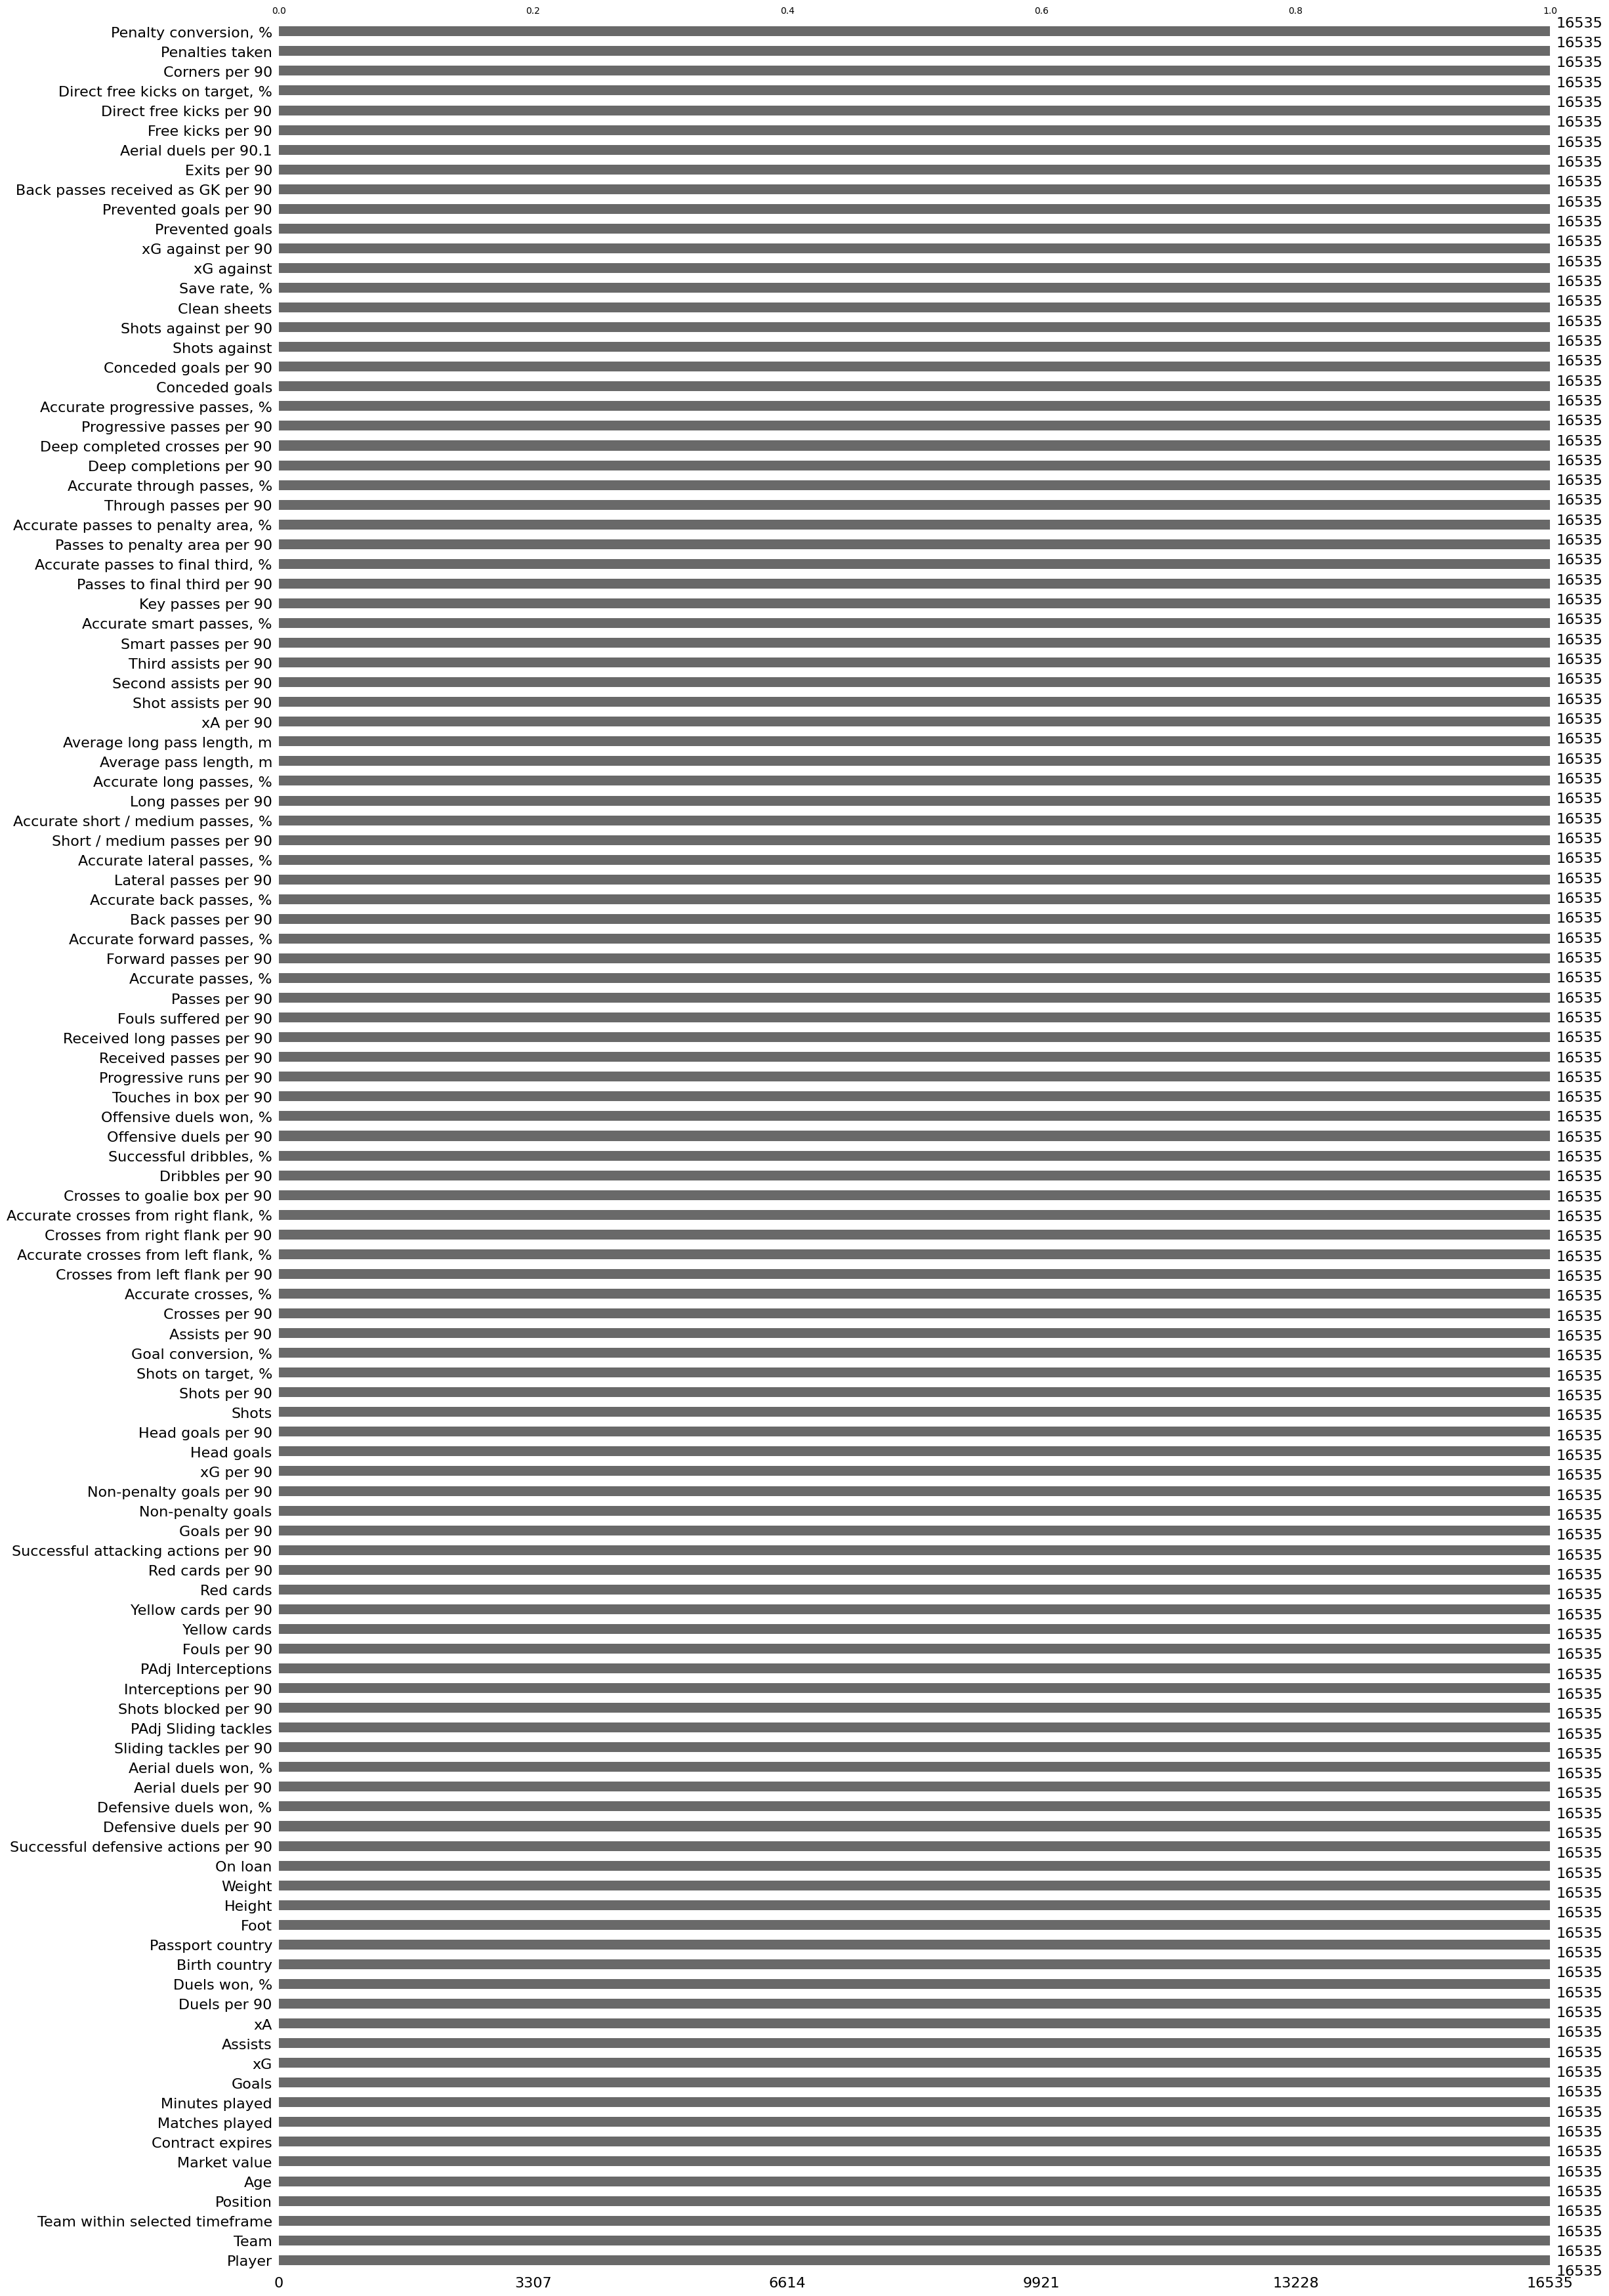

In [7]:
# Identifying numerical objects in my dataframe 
num_variables = df.select_dtypes(include=['number']).columns
obj_variables = df.select_dtypes(include=['object']).columns

# Using the mean strategy to create a simple imputer and applying them to the dataframe
# This fills the missing values in numerical columns with their respective means
nums_imputer = SimpleImputer(strategy='mean')
df[num_variables] = nums_imputer.fit_transform(df[num_variables])

# Here I created a simpleimputer using the most frequent strategy
# This fills the missing values with the most frequent value in the column
obj_imputer = SimpleImputer(strategy='most_frequent')
df[obj_variables] = obj_imputer.fit_transform(df[obj_variables])

msno.bar(df)

#### Checking for duplicates

In [8]:
duplicate_rows = df.duplicated().sum()

print(f'There are {duplicate_rows} duplicates in this dataset')

There are 0 duplicates in this dataset


### Exploratory Data Analysis

Include all exploratory Data Analysis questions you studied in this section. This is related to the sufficient and good criteria of ILO 4.1 and 4.2. 

1. What is the average age of players in the dataset?

In [9]:
df['Age'].mean() # Calculates mean

25.233859744660254

2. Which team has the highest market value on average?

In [10]:
print(df.groupby('Team')['Market value'].mean().reset_index()) #groups the team and market value columns and calculates the mean

grouped_data = df.groupby('Team')['Market value'].mean().reset_index() #same here
top_10_teams = grouped_data.nlargest(10, 'Market value') #shows the top 10 largest teams by marketvalue 


                      Team   Market value
0            1599 Şelimbăr  150000.000000
1             1860 München  307894.736842
2              1º Dezembro   41666.666667
3                       AB       0.000000
4     ACS Târgu Mureș 1898   75000.000000
...                    ...            ...
1684               Šibenik  218478.260870
1685         Široki Brijeg  300000.000000
1686              Žalgiris  305172.413793
1687                Žilina  281578.947368
1688             Žilina II   25000.000000

[1689 rows x 2 columns]


3. How does the market value of players correlate with their age?

In [11]:
correlation = df['Market value'].corr(df['Age']) #calulates correlation between two variablescolumns
print(correlation)
print('There isnt much of a correlation between the two')

0.007133053569031945
There isnt much of a correlation between the two


4. What is the distribution of players' positions across different teams?

In [12]:
position_split = df.assign(Position=df['Position'].str.split(', ')).explode('Position') # Split the position that are together like (AMF, LMF, RMF...)

position_split = position_split.groupby(['Team within selected timeframe', 'Position']).agg({"Position": [np.count_nonzero]}) #group teams and positions with the new split and not count the positions with zeros

print(position_split)


                                             Position
                                        count_nonzero
Team within selected timeframe Position              
1860 München                   AMF                  4
                               CF                   4
                               DMF                  3
                               GK                   2
                               LAMF                 3
...                                               ...
Žilina                         RCB                  3
                               RCMF                 4
                               RW                   1
                               RWB                  3
                               RWF                  2

[12020 rows x 1 columns]


5. Which country has the highest representation in the dataset in terms of player birthplace?

In [13]:
counts = df['Birth country'].value_counts().reset_index()
counts.columns = ['Birth country', 'Player Count']
birthplace_counts = counts.sort_values(by='Player Count', ascending=False)
highest_counts = birthplace_counts.iloc[0]['Birth country']
print(highest_counts)

Italy


6. Is there a correlation between a player's height and weight and the number of goals scored?

In [14]:
import seaborn as sns

correlation1 = df['Height'].corr(df['Goals']) #calulates correlation between two variablescolumns
correlation2 = df['Weight'].corr(df['Goals'])
print(f'Correlation between Height and Goals is of {correlation1}')
print(f'Correlation between Weight and Goals is of {correlation2}')

Correlation between Height and Goals is of 0.06499178577864116
Correlation between Weight and Goals is of 0.06356411494504173


7. How does the number of goals per player vary across different positions?

In [15]:
position_split = df.assign(Position=df['Position'].str.split(', ')).explode('Position') # Split the position that are together like (AMF, LMF, RMF...)

position_split = position_split.groupby(['Goals', 'Position']).agg({"Position": [np.count_nonzero]}) #group goals and positions with the new split and not count the positions with no zeros

print(position_split)

                    Position
               count_nonzero
Goals Position              
0.0   AMF                414
      CB                 436
      CF                 602
      DMF                690
      GK                1274
...                      ...
25.0  CF                   2
      RCMF                 1
26.0  CF                   1
27.0  CF                   2
30.0  CF                   1

[314 rows x 1 columns]


8. What is the average number of matches played by players in different age groups?

In [16]:
bins = [0, 18, 22, 26, 30, float('inf')] #Using bins I can get a count of a range of numbers those being the age ranges 

df['AgeRange'] = pd.cut(df['Age'], bins=bins, right=False)

# Calculate average matches played by age group
average_matches = df.groupby('AgeRange')['Matches played'].mean()

print(average_matches)

AgeRange
[0.0, 18.0)      9.122905
[18.0, 22.0)    18.262098
[22.0, 26.0)    21.372472
[26.0, 30.0)    22.124143
[30.0, inf)     22.169945
Name: Matches played, dtype: float64


C:\Users\emilp\AppData\Local\Temp\ipykernel_27156\2207266016.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['AgeRange'] = pd.cut(df['Age'], bins=bins, right=False)


9. Which players have the highest ‘xG (Expected Goals)' value and how does it compare with actual goals scored?

In [17]:
sorted = df.sort_values(by='xG', ascending=False) #sorts xG by descending order

print(sorted[['Player', 'xG']].head(5)) #prints the top 5 players by highest xG

print('')

p1 = df.query("Player=='M. Dugandžić'")['Goals'].sum() #Finds the sum of goals of the selected player
p2 = df.query("Player=='Andre Clóvis'")['Goals'].sum()
p3 = df.query("Player=='A. Compagno'")['Goals'].sum()
p4 = df.query("Player=='B. Varga'")['Goals'].sum()
p5 = df.query("Player=='G. Lapadula'")['Goals'].sum()

print(f"M. Dugandžić total Goals: {p1}")
print(f"Andre Clóvis total Goals: {p2}")
print(f"A. Compagno total Goals: {p3}")
print(f"B. Varga total Goals: {p4}")
print(f"G. Lapadula total Goals: {p5}")

             Player     xG
14051  M. Dugandžić  23.23
13157  Andre Clóvis  23.10
14422   A. Compagno  22.94
6992       B. Varga  22.85
9223    G. Lapadula  22.20

M. Dugandžić total Goals: 22.0
Andre Clóvis total Goals: 27.0
A. Compagno total Goals: 20.0
B. Varga total Goals: 26.0
G. Lapadula total Goals: 25.0


10. What is the average contract duration left for players in each team?

In [18]:
df['Contract expires'] = pd.to_datetime(df['Contract expires'])
reference_date = pd.to_datetime('2023-12-14') # The date I answered this question, it should be changed every day for accuracy
df['Contract expires in days'] = (df['Contract expires'] - reference_date).dt.days

average_contract = df.groupby('Team within selected timeframe')['Contract expires in days'].mean()
print('Contract expiry for every team in days:')
print(average_contract)


Contract expiry for every team in days:
Team within selected timeframe
1860 München     262.478261
ADO Den Haag     297.269231
AEK Athens       680.181818
AEK Larnaca      287.148148
AEL              234.950000
                    ...    
Śląsk Wrocław    306.285714
Šiauliai         113.727273
Šibenik          275.678571
Žalgiris          70.615385
Žilina           340.181818
Name: Contract expires in days, Length: 789, dtype: float64


C:\Users\emilp\AppData\Local\Temp\ipykernel_27156\380701762.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Contract expires in days'] = (df['Contract expires'] - reference_date).dt.days


11. How do ‘Duels won %' and ‘Aerial duels won %' vary by position?

In [19]:
position_split = df.assign(Position=df['Position'].str.split(', ')).explode('Position') # Split the position that are together like (AMF, LMF, RMF...)

position_split = position_split.groupby(['Duels won, %', 'Position']).agg({"Position": [np.count_nonzero]}) #group goals and positions with the new split and not count the positions with no zeros

print(position_split)

position_split = df.assign(Position=df['Position'].str.split(', ')).explode('Position') # Split the position that are together like (AMF, LMF, RMF...)

position_split = position_split.groupby(['Aerial duels won, %', 'Position']).agg({"Position": [np.count_nonzero]}) #group goals and positions with the new split and not count the positions with no zeros

print(position_split)

                           Position
                      count_nonzero
Duels won, % Position              
0.00         GK                  39
11.76        AMF                  1
             LW                   1
             RW                   1
14.29        CF                   1
...                             ...
95.65        GK                   1
96.15        GK                   1
96.30        GK                   1
96.55        GK                   1
100.00       GK                 210

[19357 rows x 1 columns]
                                  Position
                             count_nonzero
Aerial duels won, % Position              
0.0                 AMF                 36
                    CF                  54
                    DMF                  5
                    GK                  87
                    LAMF                34
...                                    ...
100.0               RCMF                 6
                    RDMF                

12. Is there a significant difference in ‘Successful defensive actions per 90' between players on loan and permanent players?

In [20]:
df_grouped = df.groupby(['Player', 'On loan', 'Successful defensive actions per 90']).size().reset_index(name='Count') # Grouping the relevant columns together 

result = df_grouped[df_grouped['On loan'] == 'yes'] # Filter only the players on loan

df_grouped2 = df.groupby(['Player', 'On loan', 'Successful defensive actions per 90']).size().reset_index(name='Count')

result2 = df_grouped2[df_grouped2['On loan'] == 'no'] # Filter only the players not on loan

print('Players on loan:')
print(result)
print("\nPlayers not on loan:")
print(result2)

Players on loan:
            Player On loan  Successful defensive actions per 90  Count
0        Dani Lual     yes                                 6.61      1
16       A. Aceves     yes                                 9.10      1
25        A. Ademi     yes                                 4.45      1
42     A. Albanese     yes                                 9.28      1
43     A. Albanese     yes                                 9.56      1
...            ...     ...                                  ...    ...
16486     Ľ. Tupta     yes                                 2.84      1
16487     Ľ. Tupta     yes                                 3.95      1
16494     Š. Beran     yes                                 6.02      1
16508    Ž. Gavrić     yes                                 4.99      1
16525     А. Buksa     yes                                 2.08      1

[1096 rows x 4 columns]

Players not on loan:
              Player On loan  Successful defensive actions per 90  Count
1       Ále

13. Which players have the highest ‘Successful attacking actions per 90' and which position do they play?

In [21]:
df_grouped = df.groupby(['Player', 'Successful attacking actions per 90', 'Position']).size().reset_index(name='Count') # Grouping the relevant columns together 

top_10_players = df_grouped.nlargest(10, 'Successful attacking actions per 90') # Gets the 10 highest players by Successful attacking actions per 90

print('Top 10 highest players by "Successful attacking actions per 90":')
print('')
print(top_10_players)


Top 10 highest players by "Successful attacking actions per 90":

                    Player  Successful attacking actions per 90  \
2616            C. Madueke                                15.95   
5265   Francisco Conceicão                                15.30   
12280             O. Niang                                12.54   
2132             B. Ozlavo                                12.00   
4161          E. Daskevics                                11.90   
8014             K. Cruise                                11.25   
2561             C. Jebara                                11.07   
16259             Z. Jones                                11.01   
11428       Miguel Tavares                                10.84   
2361            Bruno Gama                                10.73   

            Position  Count  
2616       RAMF, RWF      1  
5265   RWF, RAMF, RW      1  
12280        LW, LWF      1  
2132              CF      1  
4161         LWB, LW      1  
8014         LWB

14. What is the relationship between ‘Goals per 90' and ‘Assists per 90' for forwards?

In [22]:
selected = ['AMF', 'LWF', 'RWF', 'LW', 'RW', 'CF', 'LAMF', 'RAMF'] # Selecting the relevant positons to a forward
forward = df[df['Position'].isin(selected)] # Filters only the selected position from the position column

corr = df['Goals per 90'].corr(df['Assists per 90']) # Makes a correlation coefficient for the selected columns
print(f'correlation coefficient between both columns: {corr}')

correlation coefficient between both columns: 0.23539786073961483


15. Which players exceed in ‘Shots on target %' and how does it relate to their overall ‘Goal conversion %'?

In [23]:
df_grouped = df.groupby(['Player', 'Shots on target, %', 'Goal conversion, %']).size().reset_index(name='Count') #Groups the relevant columns together

top_10_player = df_grouped.nlargest(20, 'Shots on target, %') # Gets the 20 highest players based on shots on target, %
print(top_10_player)

             Player  Shots on target, %  Goal conversion, %  Count
4      A. Abdennour               100.0               0.000      1
63     A. Andersson               100.0               0.000      1
69    A. Androutsos               100.0             100.000      1
101           A. Ba               100.0               0.000      1
206        A. Boyle               100.0             100.000      1
231        A. Bárta               100.0             100.000      1
292      A. Circati               100.0               0.000      1
392    A. Dmitrijev               100.0              33.333      1
712        A. Jatta               100.0               0.000      1
720      A. Jenssen               100.0              20.000      1
735      A. Julloux               100.0               0.000      1
742        A. Järve               100.0               0.000      1
829       A. Krešić               100.0               0.000      1
850    A. Lambrughi               100.0               0.000   

16. How do ‘Passes per 90' and ‘Accurate passes %' correlate for midfielders?

In [24]:
selected = ['AMF', 'DMF', 'LCMF', 'RCMF', 'RAMF', 'LAMF'] # Selecting the relevant positons to a midfielder
forward2 = df[df['Position'].isin(selected)] # Filters only the selected position from the position column


17. Is there a trend in the ‘Save rate %' for goalkeepers across different age groups?

In [25]:
selected = ['GK'] # Selecting the relevant positons to a gk, which there is only one
forward3 = df[df['Position'].isin(selected)] # Filters only the selected position from the position column

bins = [0, 18, 22, 26, 30, float('inf')] #Using bins I can get a count of a range of numbers those being the age ranges 

forward3.loc[:, 'AgeRange'] = pd.cut(forward3['Age'], bins=bins, right=False)

save_rate = forward3.groupby('AgeRange')['Save rate, %'].apply(list)

save_rate2 = forward3.groupby('AgeRange')['Save rate, %'].mean()

print(save_rate)

print('\nAverage Save rate, % per age group')
print(save_rate2)
print('\nThere is a clear trend here. As the age increases so does the save rate %')

AgeRange
[0.0, 18.0)     [58.06, 73.68, 60.0, 80.95, 60.71, 71.0, 71.43...
[18.0, 22.0)    [72.0, 69.48, 68.42, 65.08, 63.93, 73.87, 63.1...
[22.0, 26.0)    [74.29, 72.82, 73.43, 74.24, 70.71, 60.0, 68.8...
[26.0, 30.0)    [68.97, 45.45, 68.18, 63.46, 73.64, 64.34, 68....
[30.0, inf)     [71.3, 62.14, 78.69, 69.57, 67.59, 74.42, 62.3...
Name: Save rate, %, dtype: object

Average Save rate, % per age group
AgeRange
[0.0, 18.0)     65.290000
[18.0, 22.0)    67.726431
[22.0, 26.0)    67.899529
[26.0, 30.0)    68.791667
[30.0, inf)     69.093294
Name: Save rate, %, dtype: float64

There is a clear trend here. As the age increases so does the save rate %


18. What is the distribution of ‘Yellow cards per 90' and ‘Red cards per 90' across different positions?

In [26]:
position_split = df.assign(Position=df['Position'].str.split(', ')).explode('Position') # Split the position that are together like (AMF, LMF, RMF...)

position_split = position_split.groupby(['Yellow cards per 90', 'Position']).agg({"Position": [np.count_nonzero]}) #group teams and positions with the new split and not count the positions with zeros

print(position_split)

position_split2 = df.assign(Position=df['Position'].str.split(', ')).explode('Position') # Split the position that are together like (AMF, LMF, RMF...)

position_split2 = position_split2.groupby(['Red cards per 90', 'Position']).agg({"Position": [np.count_nonzero]}) #group teams and positions with the new split and not count the positions with zeros

print(position_split2)

                                  Position
                             count_nonzero
Yellow cards per 90 Position              
0.00                AMF                259
                    CB                  61
                    CF                 639
                    DMF                 71
                    GK                 523
...                                    ...
1.88                LCMF                 1
                    RCMF                 1
1.91                LAMF                 1
                    LW                   1
                    RAMF                 1

[1595 rows x 1 columns]
                               Position
                          count_nonzero
Red cards per 90 Position              
0.00             AMF               1586
                 CB                 677
                 CF                3220
                 DMF               1065
                 GK                1202
...                                 ...
0.72         

19. How does ‘Fouls suffered per 90' compare for attackers and defenders?

In [27]:
selected = ['AMF', 'LWF', 'RWF', 'LW', 'RW', 'CF', 'LAMF', 'RAMF'] # Selecting the relevant positons to an attacker
forward = df[df['Position'].isin(selected)] # Filters only the selected position from the position column
print('Fouls suffered per 90 for attackers:')
print(forward['Fouls suffered per 90'])

selected2 = ['RCB', 'LCB', 'LB', 'RB', 'CB'] # Selecting the relevant positons to an attacker
defender = df[df['Position'].isin(selected2)] # Filters only the selected position from the position column
print('\nFouls suffered for defenders:')
print(defender['Fouls suffered per 90'])

Fouls suffered per 90 for attackers:
12       1.25
13       1.20
24       0.67
26       2.05
35       1.82
         ... 
16489    1.44
16492    1.03
16494    1.22
16497    1.35
16527    0.18
Name: Fouls suffered per 90, Length: 1734, dtype: float64

Fouls suffered for defenders:
3        0.23
5        0.18
8        0.77
14       0.31
16       1.20
         ... 
16510    0.30
16511    0.00
16512    1.18
16518    0.16
16534    0.91
Name: Fouls suffered per 90, Length: 2304, dtype: float64


20. Which players have the highest ‘Penalty conversion %' and what are their overall shooting statistics?

In [28]:
df_grouped = df.groupby(['Player', 'Penalty conversion, %', 'Shots on target, %', 'Shots per 90', 'Shots']).size().reset_index(name='Count') #Groups the relevant columns together

top_10_player = df_grouped.nlargest(10, 'Penalty conversion, %') # Gets the 20 highest players based on shots on target, %
print(top_10_player)


               Player  Penalty conversion, %  Shots on target, %  \
2        A.  Lőrinczy                  100.0               32.69   
28        A. Adorante                  100.0               47.50   
31   A. Ahl Holmström                  100.0               51.35   
33         A. Ahmetaj                  100.0               40.00   
82           A. Arena                  100.0               33.33   
87        A. Arrigoni                  100.0               22.73   
107        A. Bajrami                  100.0               31.25   
113        A. Balajti                  100.0               33.33   
115          A. Baldé                  100.0               28.89   
123        A. Barillà                  100.0               44.44   

     Shots per 90  Shots  Count  
2            3.19  104.0      1  
28           2.18   40.0      1  
31           2.92   37.0      1  
33           0.76   15.0      1  
82           1.66   60.0      1  
87           1.38   44.0      1  
107          

### Visualizations

Include all the visualizations you made in this section. This is related to the excellent criteria of ILO 4.2. Use the blocks below to enter the code for graphs you created with matplotlib (or seaborn, bokeh, or another visualization package). 

❗ If you would like to showcast your visualizations using streamlit, you need to hand in a seperate .py file for this. It is not possible to run streamlit code from a python notebook. Please note down below if you do so.

##### The top 10 teams by Mean Market Value

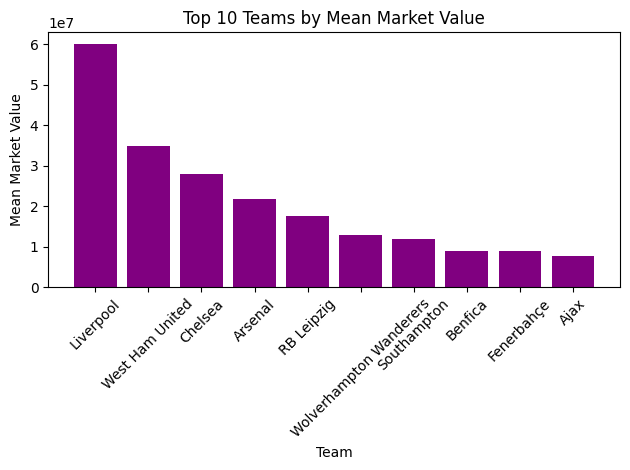

In [29]:
fig, ax = plt.subplots()

ax.bar(top_10_teams['Team'], top_10_teams['Market value'], color='purple') #makes a bar chart of the top 10 teams by marketvalue 
plt.xticks(rotation=45)
plt.title('Top 10 Teams by Mean Market Value')
plt.xlabel('Team')
plt.ylabel('Mean Market Value')
plt.tight_layout()

plt.show()

##### The top 15 goal scorers in the dataset

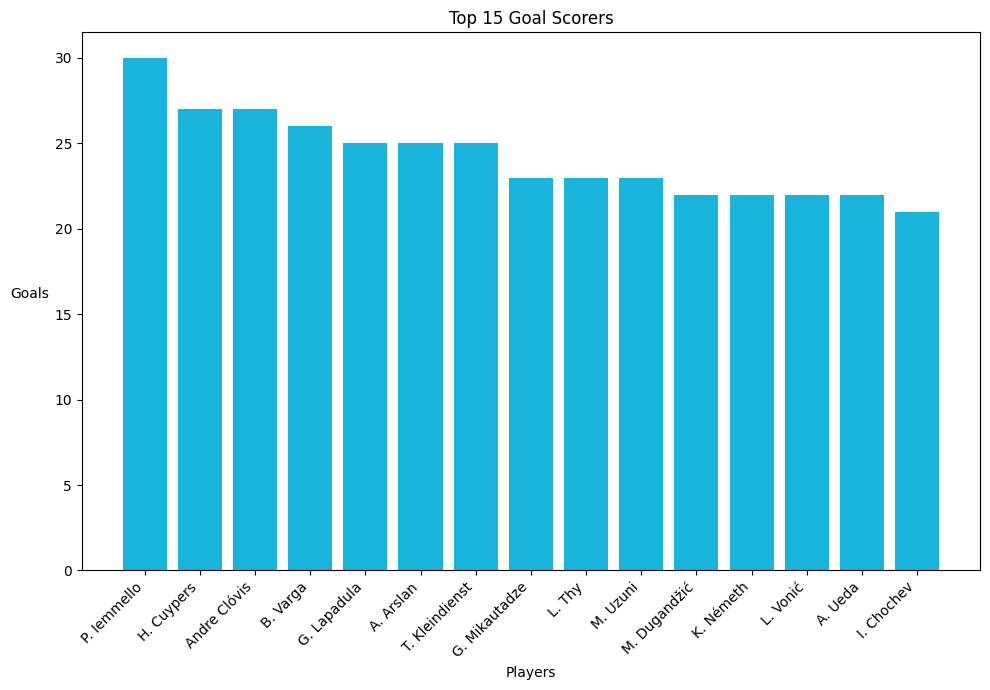

In [30]:
top_scorers = df.sort_values(by='Goals', ascending=False).head(15)

players = top_scorers['Player']
goals = top_scorers['Goals']

plt.figure(figsize=(10, 7))
plt.bar(players, goals, color='#18b4db')
plt.title('Top 15 Goal Scorers')
plt.xlabel('Players')
plt.ylabel('Goals', rotation=0, ha='right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

##### A scatter plot of Goals vs xG

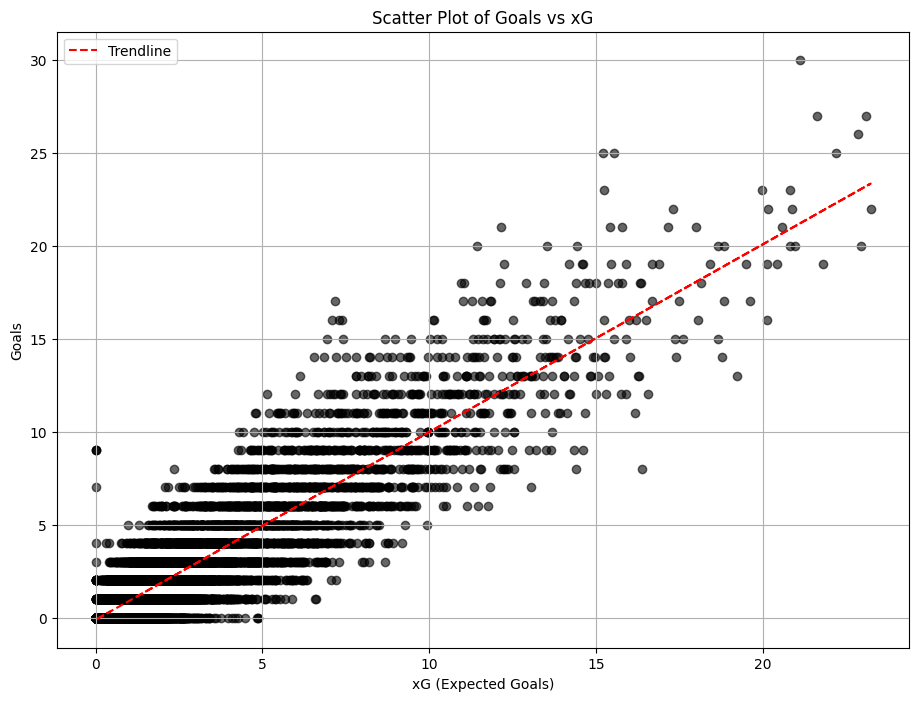

In [31]:
plt.figure(figsize=(11, 8))
plt.scatter(df['xG'], df['Goals'], color='black', alpha=0.6) 
plt.title('Scatter Plot of Goals vs xG')
plt.xlabel('xG (Expected Goals)')
plt.ylabel('Goals')
plt.grid(True)

z = np.polyfit(df['xG'], df['Goals'], 1)
p = np.poly1d(z)
plt.plot(df['xG'], p(df['xG']), color='red', linestyle='--', label='Trendline')

plt.legend()
plt.show()

##### Antother scatter plot of Assists vs xA

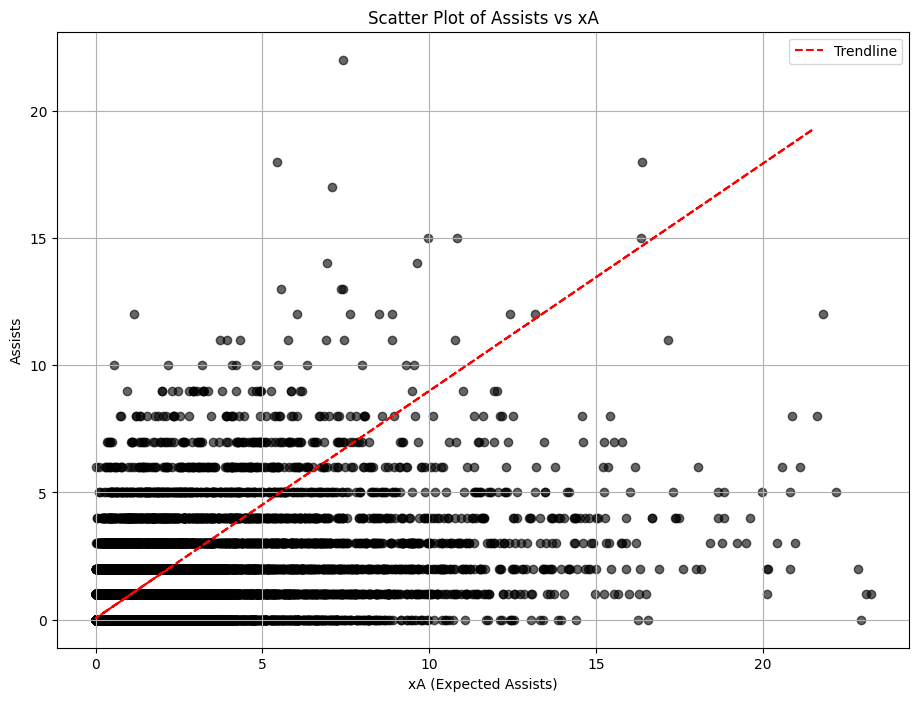

In [32]:
plt.figure(figsize=(11, 8))
plt.scatter(df['xG'], df['Assists'], color='black', alpha=0.6) 
plt.title('Scatter Plot of Assists vs xA')
plt.xlabel('xA (Expected Assists)')
plt.ylabel('Assists')
plt.grid(True)

z = np.polyfit(df['xA'], df['Assists'], 1)
p = np.poly1d(z)
plt.plot(df['xA'], p(df['xA']), color='red', linestyle='--', label='Trendline')

plt.legend()
plt.show()

Correlation between passes per 90 and accurate passes, % for midfielders

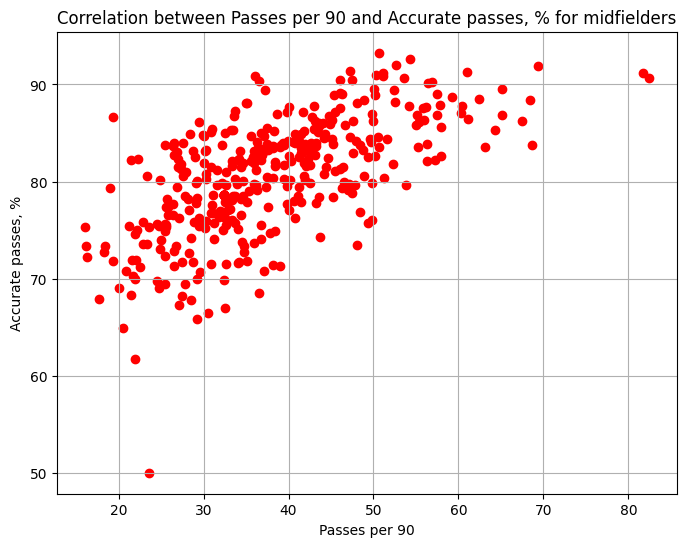

In [33]:
plt.figure(figsize=(8, 6))
plt.scatter(forward2['Passes per 90'], forward2['Accurate passes, %'], color='r') # Creates a scatter plot based on Passes per 90 and Accurate passes, % for the selected positions
plt.title('Correlation between Passes per 90 and Accurate passes, % for midfielders')
plt.xlabel('Passes per 90')
plt.ylabel('Accurate passes, %')
plt.grid(True)
plt.show()

Relationship between Goals per 90 and Assists per 90 for forwards

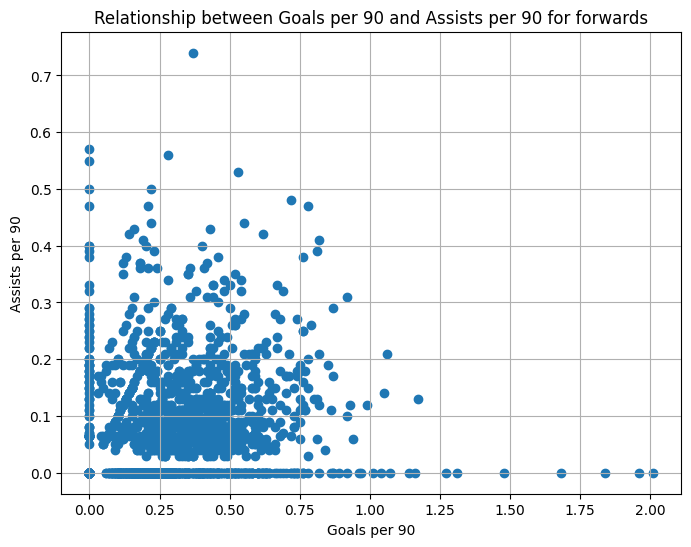

In [34]:
plt.figure(figsize=(8, 6))
plt.scatter(forward['Goals per 90'], forward['Assists per 90']) # Creates a scatter plot based on Goals per 90 and Assists per 90 for the selected positions
plt.title('Relationship between Goals per 90 and Assists per 90 for forwards')
plt.xlabel('Goals per 90')
plt.ylabel('Assists per 90')
plt.grid(True)
plt.show()

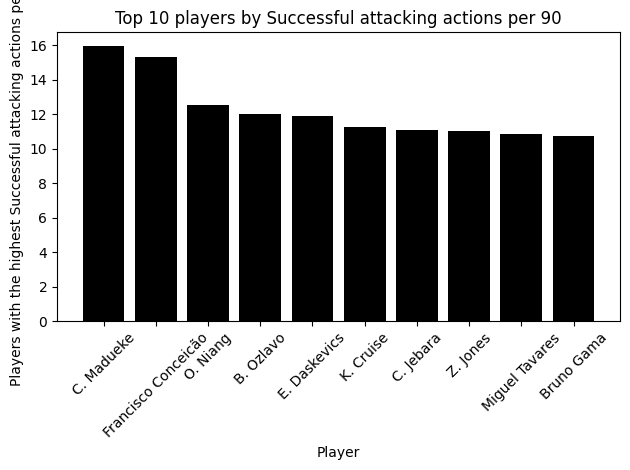

In [35]:
fig, ax = plt.subplots()

ax.bar(top_10_players['Player'], top_10_players['Successful attacking actions per 90'], color='black') #makes a bar chart of the top 10 teams by marketvalue 
plt.xticks(rotation=45)
plt.title('Top 10 players by Successful attacking actions per 90')
plt.xlabel('Player')
plt.ylabel('Players with the highest Successful attacking actions per 90')
plt.tight_layout()

plt.show()

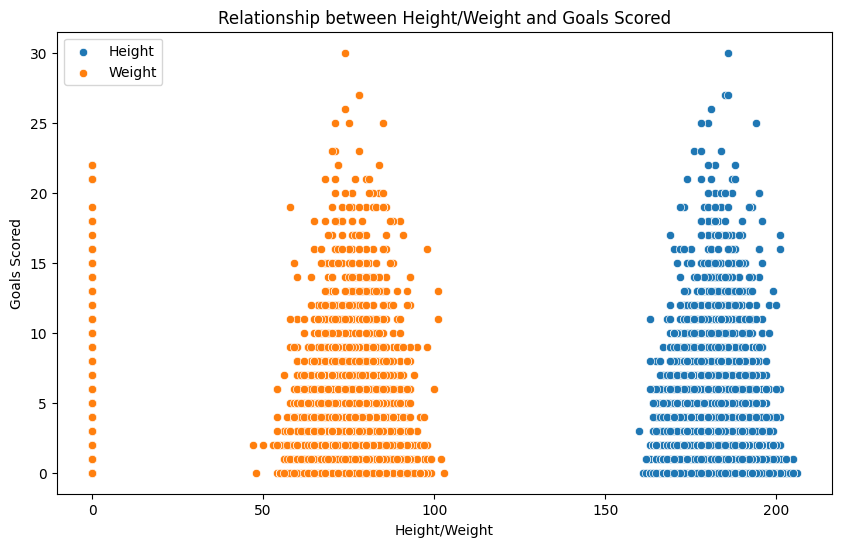

In [36]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Height', y='Goals', data=df, label='Height')
sns.scatterplot(x='Weight', y='Goals', data=df, label='Weight')
plt.title("Relationship between Height/Weight and Goals Scored")
plt.xlabel("Height/Weight")
plt.ylabel("Goals Scored")
plt.legend()
plt.show()


#### Getting Gifs using API:

In [101]:
API_KEY = "gLqV9BmJImHYKILb2Ex0fnrQF4alUvzj"
SEARCH_ENDPOINT = "https://api.giphy.com/v1/gifs/search"

search_term = "sad"
params = {"api_key": API_KEY, "limit": 1, "q": search_term, "rating": "g"}
response = requests.get(SEARCH_ENDPOINT, params=params).json()

for gif in response["data"]:
    title = gif["title"]
    url = gif["url"]
    print(f"{title} | {url}")

Sad Cry GIF by SpongeBob SquarePants | https://giphy.com/gifs/spongebob-squarepants-sad-OPU6wzx8JrHna


#### My SQL: Database Operations.

In [ ]:
from getpass import getpass
from mysql.connector import connect, Error

try:
    with connect(E
        host="localhost",
        user=input("Enter username: "),
        password=getpass("Enter password: "),
    ) as connection:
        print(connection)
except Error as e:
    print(e)

In [ ]:
from getpass import getpass
from mysql.connector import connect, Error

try:
    with connect(
        host="localhost",
        user=input("Enter username: "),
        password=getpass("Enter password: "),
    ) as connection:
        create_db_query = "CREATE DATABASE online_movie_rating241"
        with connection.cursor() as cursor:
            cursor.execute(create_db_query)
except Error as e:
    print(e)

In [ ]:
connection = mysql.connector.connect(user='Emil_Fox', password='password', host='localhost')

show_db_query = "SHOW DATABASES"
with connection.cursor() as cursor:
     cursor.execute(show_db_query)
     for db in cursor:
         print(db)

('information_schema',)
('mysql',)
('online_movie_rating',)
('online_movie_rating22',)
('online_movie_rating241',)
('performance_schema',)
('sys',)


In [ ]:
try:
    with connect(
        host="localhost",
        user=input("Enter username: "),
        password=getpass("Enter password: "),
        database="online_movie_rating",
    ) as connection:
        print(connection)
except Error as e:
    print(e)

In [ ]:
connection = mysql.connector.connect(user='Emil_Fox', password='password', host='localhost')

database_name = 'online_movie_rating'
connection.database = database_name

create_movies_table_query = """
CREATE TABLE movies222(
    id INT AUTO_INCREMENT PRIMARY KEY,
    title VARCHAR(100),
    release_year YEAR(4),
    genre VARCHAR(100),
    collection_in_mil INT
)
"""
with connection.cursor() as cursor:
    cursor.execute(create_movies_table_query)
    connection.commit()

In [ ]:
create_reviewers_table_query = """
CREATE TABLE reviewers222 (
    id INT AUTO_INCREMENT PRIMARY KEY,
    first_name VARCHAR(100),
    last_name VARCHAR(100)
)
"""
with connection.cursor() as cursor:
    cursor.execute(create_reviewers_table_query)
    connection.commit()

In [ ]:
create_ratings_table_query = """
CREATE TABLE ratings222 (
    movie_id INT,
    reviewer_id INT,
    rating DECIMAL(2,1),
    FOREIGN KEY(movie_id) REFERENCES movies(id),
    FOREIGN KEY(reviewer_id) REFERENCES reviewers(id),
    PRIMARY KEY(movie_id, reviewer_id)
)
"""
with connection.cursor() as cursor:
    cursor.execute(create_ratings_table_query)
    connection.commit()

In [ ]:
show_table_query = "DESCRIBE movies"
with connection.cursor() as cursor:
     cursor.execute(show_table_query)
     # Fetch rows from last executed query
     result = cursor.fetchall()
     for row in result:
         print(row)

('id', 'int', 'NO', 'PRI', None, 'auto_increment')
('title', 'varchar(100)', 'YES', '', None, '')
('release_year', 'year', 'YES', '', None, '')
('genre', 'varchar(100)', 'YES', '', None, '')
('collection_in_mil', 'decimal(4,1)', 'YES', '', None, '')


In [ ]:
alter_table_query = """
... ALTER TABLE movies
... MODIFY COLUMN collection_in_mil DECIMAL(4,1)
... """
show_table_query = "DESCRIBE movies"
with connection.cursor() as cursor:
     cursor.execute(alter_table_query)
     cursor.execute(show_table_query)
     # Fetch rows from last executed query
     result = cursor.fetchall()
     print("Movie Table Schema after alteration:")
     for row in result:
         print(row)


Movie Table Schema after alteration:
('id', 'int', 'NO', 'PRI', None, 'auto_increment')
('title', 'varchar(100)', 'YES', '', None, '')
('release_year', 'year', 'YES', '', None, '')
('genre', 'varchar(100)', 'YES', '', None, '')
('collection_in_mil', 'decimal(4,1)', 'YES', '', None, '')


In [ ]:
insert_movies_query = """
INSERT INTO movies (title, release_year, genre, collection_in_mil)
VALUES
    ("Forrest Gump", 1994, "Drama", 330.2),
    ("3 Idiots", 2009, "Drama", 2.4),
    ("Eternal Sunshine of the Spotless Mind", 2004, "Drama", 34.5),
    ("Good Will Hunting", 1997, "Drama", 138.1),
    ("Skyfall", 2012, "Action", 304.6),
    ("Gladiator", 2000, "Action", 188.7),
    ("Black", 2005, "Drama", 3.0),
    ("Titanic", 1997, "Romance", 659.2),
    ("The Shawshank Redemption", 1994, "Drama",28.4),
    ("Udaan", 2010, "Drama", 1.5),
    ("Home Alone", 1990, "Comedy", 286.9),
    ("Casablanca", 1942, "Romance", 1.0),
    ("Avengers: Endgame", 2019, "Action", 858.8),
    ("Night of the Living Dead", 1968, "Horror", 2.5),
    ("The Godfather", 1972, "Crime", 135.6),
    ("Haider", 2014, "Action", 4.2),
    ("Inception", 2010, "Adventure", 293.7),
    ("Evil", 2003, "Horror", 1.3),
    ("Toy Story 4", 2019, "Animation", 434.9),
    ("Air Force One", 1997, "Drama", 138.1),
    ("The Dark Knight", 2008, "Action",535.4),
    ("Bhaag Milkha Bhaag", 2013, "Sport", 4.1),
    ("The Lion King", 1994, "Animation", 423.6),
    ("Pulp Fiction", 1994, "Crime", 108.8),
    ("Kai Po Che", 2013, "Sport", 6.0),
    ("Beasts of No Nation", 2015, "War", 1.4),
    ("Andadhun", 2018, "Thriller", 2.9),
    ("The Silence of the Lambs", 1991, "Crime", 68.2),
    ("Deadpool", 2016, "Action", 363.6),
    ("Drishyam", 2015, "Mystery", 3.0)
"""
with connection.cursor() as cursor:
    cursor.execute(insert_movies_query)
    connection.commit()

In [ ]:
insert_reviewers_query = """
INSERT INTO reviewers
(first_name, last_name)
VALUES ( %s, %s )
"""
reviewers_records = [
    ("Chaitanya", "Baweja"),
    ("Mary", "Cooper"),
    ("John", "Wayne"),
    ("Thomas", "Stoneman"),
    ("Penny", "Hofstadter"),
    ("Mitchell", "Marsh"),
    ("Wyatt", "Skaggs"),
    ("Andre", "Veiga"),
    ("Sheldon", "Cooper"),
    ("Kimbra", "Masters"),
    ("Kat", "Dennings"),
    ("Bruce", "Wayne"),
    ("Domingo", "Cortes"),
    ("Rajesh", "Koothrappali"),
    ("Ben", "Glocker"),
    ("Mahinder", "Dhoni"),
    ("Akbar", "Khan"),
    ("Howard", "Wolowitz"),
    ("Pinkie", "Petit"),
    ("Gurkaran", "Singh"),
    ("Amy", "Farah Fowler"),
    ("Marlon", "Crafford"),
]
with connection.cursor() as cursor:
    cursor.executemany(insert_reviewers_query, reviewers_records)
    connection.commit()

In [ ]:
select_movies_query = "SELECT * FROM movies LIMIT 5"
with connection.cursor() as cursor:
     cursor.execute(select_movies_query)
     result = cursor.fetchall()
     for row in result:
         print(row)

(1, 'Forrest Gump', 1994, 'Drama', Decimal('330.2'))
(2, '3 Idiots', 2009, 'Drama', Decimal('2.4'))
(3, 'Eternal Sunshine of the Spotless Mind', 2004, 'Drama', Decimal('34.5'))
(4, 'Good Will Hunting', 1997, 'Drama', Decimal('138.1'))
(5, 'Skyfall', 2012, 'Action', Decimal('304.6'))


In [ ]:
select_movies_query = "SELECT title, release_year FROM movies LIMIT 5"
with connection.cursor() as cursor:
     cursor.execute(select_movies_query)
     for row in cursor.fetchall():
         print(row)

('Forrest Gump', 1994)
('3 Idiots', 2009)
('Eternal Sunshine of the Spotless Mind', 2004)
('Good Will Hunting', 1997)
('Skyfall', 2012)


In [ ]:
elect_movies_query = """
... SELECT title, collection_in_mil
... FROM movies
... WHERE collection_in_mil > 300
... ORDER BY collection_in_mil DESC
... """
with connection.cursor() as cursor:
     cursor.execute(select_movies_query)
     for movie in cursor.fetchall():
         print(movie)

('Forrest Gump', 1994)
('3 Idiots', 2009)
('Eternal Sunshine of the Spotless Mind', 2004)
('Good Will Hunting', 1997)
('Skyfall', 2012)


In [ ]:
select_movies_query = """
... SELECT CONCAT(title, " (", release_year, ")"),
...       collection_in_mil
... FROM movies
... ORDER BY collection_in_mil DESC
... LIMIT 5
... """
with connection.cursor() as cursor:
     cursor.execute(select_movies_query)
     for movie in cursor.fetchall():
         print(movie)

('Avengers: Endgame (2019)', Decimal('858.8'))
('Avengers: Endgame (2019)', Decimal('858.8'))
('Avengers: Endgame (2019)', Decimal('858.8'))
('Titanic (1997)', Decimal('659.2'))
('Titanic (1997)', Decimal('659.2'))


In [ ]:
select_movies_query = """
... SELECT title, AVG(rating) as average_rating
... FROM ratings
... INNER JOIN movies
...     ON movies.id = ratings.movie_id
... GROUP BY movie_id
... ORDER BY average_rating DESC
... LIMIT 5
... """
with connection.cursor() as cursor:
     cursor.execute(select_movies_query)
     for movie in cursor.fetchall():
         print(movie)

('The Godfather', Decimal('9.90000'))
('Night of the Living Dead', Decimal('9.90000'))
('Avengers: Endgame', Decimal('9.75000'))
('Eternal Sunshine of the Spotless Mind', Decimal('8.90000'))
('Beasts of No Nation', Decimal('8.70000'))


In [ ]:
select_movies_query = """
... SELECT CONCAT(first_name, " ", last_name), COUNT(*) as num
... FROM reviewers
... INNER JOIN ratings
...     ON reviewers.id = ratings.reviewer_id
... GROUP BY reviewer_id
... ORDER BY num DESC
... LIMIT 1
... """
>>> with connection.cursor() as cursor:
...     cursor.execute(select_movies_query)
...     for movie in cursor.fetchall():
...         print(movie)

('Mary Cooper', 4)


In [ ]:
update_query = """
UPDATE
    reviewers
SET
    last_name = "Cooper"
WHERE
    first_name = "Amy"
"""
with connection.cursor() as cursor:
    cursor.execute(update_query)
    connection.commit()

In [ ]:
from getpass import getpass
from mysql.connector import connect, Error

movie_id = input("Enter movie id: ")
reviewer_id = input("Enter reviewer id: ")
new_rating = input("Enter new rating: ")
update_query = """
UPDATE
    ratings
SET
    rating = "%s"
WHERE
    movie_id = "%s" AND reviewer_id = "%s";

SELECT *
FROM ratings
WHERE
    movie_id = "%s" AND reviewer_id = "%s"
""" % (
    new_rating,
    movie_id,
    reviewer_id,
    movie_id,
    reviewer_id,
)

try:
    with connect(
        host="localhost",
        user=input("Enter username: "),
        password=getpass("Enter password: "),
        database="online_movie_rating",
    ) as connection:
        with connection.cursor() as cursor:
            for result in cursor.execute(update_query, multi=True):
                if result.with_rows:
                    print(result.fetchall())
            connection.commit()
except Error as e:
    print(e)

[]


In [ ]:
connection = mysql.connector.connect(user='Emil_Fox', password='password', host='localhost')

movie_id = input("Enter movie id: ")
reviewer_id = input("Enter reviewer id: ")
new_rating = input("Enter new rating: ")
update_query = """
UPDATE
    ratings
SET
    rating = %s
WHERE
    movie_id = %s AND reviewer_id = %s;

SELECT *
FROM ratings
WHERE
    movie_id = %s AND reviewer_id = %s
"""
val_tuple = (
    new_rating,
    movie_id,
    reviewer_id,
    movie_id,
    reviewer_id,
)

try:
    with connect(
        host="localhost",
        user=input("Enter username: "),
        password=getpass("Enter password: "),
        database="online_movie_rating",
    ) as connection:
        with connection.cursor() as cursor:
            for result in cursor.execute(update_query, val_tuple, multi=True):
                if result.with_rows:
                    print(result.fetchall())
            connection.commit()
except Error as e:
    print(e)

[(18, 15, Decimal('5.0'))]


## Machine Learning

### Identifying basic Machine Learning applications.
In the following subsection, show your understanding of each of the listed Machine Learning algorithms. Excecute these algorithms on the NAC dataset. This is related to the poor (and insufficient) criteria of ILO 5.0. 

❗Remember! All your package imports should be on top of this notebook.

#### Before doing anything, I will split all of the positions that have been joined together so that they can be used properly going forward

In [38]:
# Split the position that are together like (AMF, LMF, RMF...)
df = df.assign(Position=df['Position'].str.split(', ')).explode('Position') 

#### Simple machine learning modelling pipeline

In [39]:
# Selecting the target variable/s and defining x and y
X = df2.drop(['Goals'], axis='columns')
y = df2['Goals']

# Using a simple imputer to fill in the NaN values with the mean strategy
imputer = SimpleImputer(strategy='mean') 
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_imputed_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X.columns)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_imputed_scaled, y, test_size=0.2, random_state=42)

# Choosing a model
model = DecisionTreeClassifier(random_state=42)

#Fitting the model
model.fit(X_train, y_train)

# Making predictions for the model
y_pred = model.predict(X_test)

# Calculating the accuracy score
accuracy = accuracy_score(y_test, y_pred)

accuracy

0.9661324463259752

Every machine learning modelling pipeline is slightly different for different models but this is the general pipeline that I will use. First I define the target and features, the X and y. Then I use a simple Imputer to fill in the missing values with the mean of everything else in the column. Then I apply the imputer to the columns. Then I add a scaler to it which standardizes the features and converts the result back into a df, it makes the code run faster. After that, I split the dataset into training and testing sets, which right after that you have to choose a model to work with, in this case it is the DecisionTreeClassifier, but you can choose any other model. Then we fit the model, make preductions and calculate the accuracy score. 

#### Linear regression

##### General Multiple Linear Regression of Market Value vs predicted Market Value:

MSE score for this model: 1509276357175.4404
R2 score for this model: 0.08231359023344942


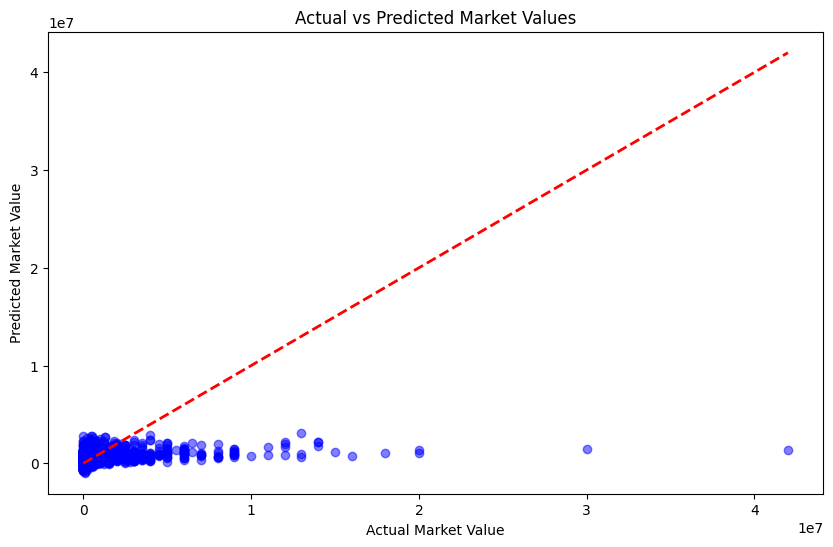

In [40]:
 # The stats used to calculate the scores
features = ['Age', 'Goals', 'Assists', 'xG', 'xA', 'Goal conversion, %', 'Accurate passes, %', 'Accurate crosses, %', 
            'Goals per 90', 'Assists per 90', 'Shots', 'Red cards', 'Weight', 'Height', 'Minutes played', 'Matches played', 
            'Penalties taken', 'Penalty conversion, %']
X_multiple = df[features]

# The target variable
y = df['Market value'] 

# Impute missing values using the mean
imputer = SimpleImputer(strategy='mean') 
X_multiple_imputed = imputer.fit_transform(X_multiple)

# Split the dataset into training and testing sets
X_train_multiple, X_test_multiple, y_train, y_test = train_test_split(X_multiple_imputed, y, test_size=0.2, random_state=42)

# Create linear regression model
multiple_model = LinearRegression()

# Fit the model to the training data
multiple_model.fit(X_train_multiple, y_train)

y_pred_multiple = multiple_model.predict(X_test_multiple)

# Evaluate the model with multiple metrics
multiple_mse = mean_squared_error(y_test, y_pred_multiple)
multiple_r2 = r2_score(y_test, y_pred_multiple)

print(f'MSE score for this model: {multiple_mse}')
print(f'R2 score for this model: {multiple_r2}')

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_multiple, color='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', linewidth=2)
plt.title('Actual vs Predicted Market Values')
plt.xlabel('Actual Market Value')
plt.ylabel('Predicted Market Value')
plt.show()


##### Linear Regression of Market Value vs Predicted Market Value for Goalkeeper position:

MSE score for this model: 1238562853081.5613
R2 score for this model: 0.12461225037781343
Accuracy score: 12.461225037781343 %


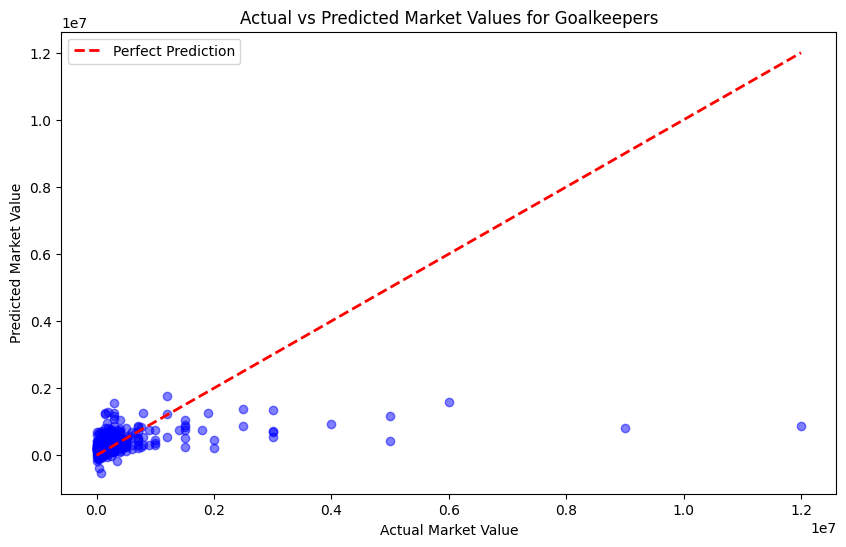

In [41]:
# Creates a new column where 1 means its a 'GK' and 0 means its not a 'GK'
df['IsGoalkeeper'] = df['Position'].apply(lambda x: 1 if isinstance(x, str) and 'GK' in x else 0) 

# This filters the IsGoalkeeper column so that it only uses the 1s so only if its says its a 'Gk'
goalkeeper_data = df[df['IsGoalkeeper'] == 1] 

features = ['Age', 'Clean sheets', 'Prevented goals', 'Prevented goals per 90', 'Save rate, %', 'xG against', 'Conceded goals', 
            'Conceded goals per 90', 'Back passes received as GK per 90', 'xG against per 90', 'Height', 'Weight', 'Minutes played', 
            'Matches played', 'Duels per 90', 'Duels won, %', 'Successful defensive actions per 90', 'Yellow cards', 'Shots against', 
            'Shots against per 90']
X_goalkeeper = goalkeeper_data[features]
y_goalkeeper = goalkeeper_data['Market value']

imputer = SimpleImputer(strategy='mean')
X_goalkeeper_imputed = imputer.fit_transform(X_goalkeeper)

X_train, X_test, y_train, y_test = train_test_split(X_goalkeeper_imputed, y_goalkeeper, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE score for this model: {mse}')
print(f'R2 score for this model: {r2}')
percentage = r2 * 100
print(f'Accuracy score: {percentage} %')

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
plt.title('Actual vs Predicted Market Values for Goalkeepers')
plt.xlabel('Actual Market Value')
plt.ylabel('Predicted Market Value')
plt.legend()
plt.show()

##### Linear Regression of Market Value vs Predicted Market Value for Attackers:

MSE score for this model: 2621174744058.1816
R2 score for this model: 0.10282213614363589


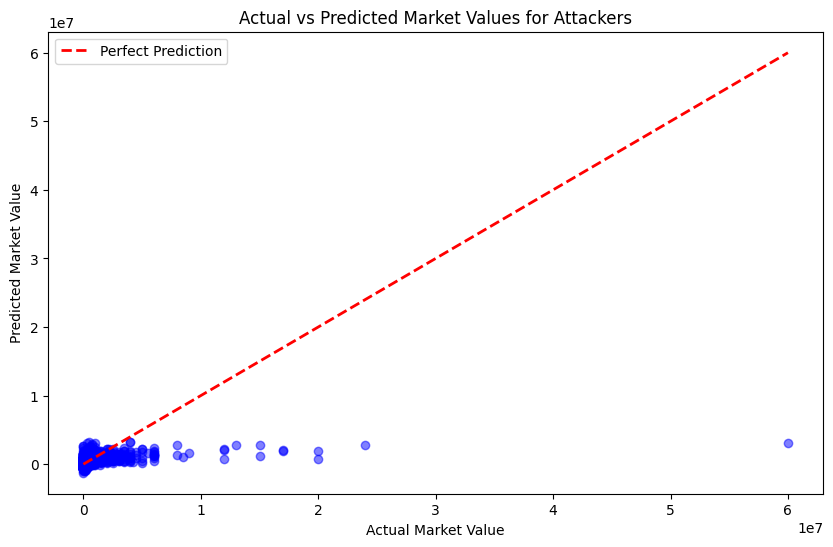

In [42]:
positions_to_check = ['RW', 'AMF', 'CF', 'LWF', 'RWF', 'LW']

df['IsAttacker'] = df['Position'].apply(lambda x: 1 if isinstance(x, str) and any(pos in x for pos in positions_to_check) else 0) 

# This filters the IsGoalkeeper column so that it only uses the 1s so only if its says its a 'Gk'
attacker_data = df[df['IsAttacker'] == 1] 

features = ['Age', 'Height', 'Weight', 'Minutes played', 'Matches played', 'Yellow cards',
            'Penalties taken', 'Penalty conversion, %', 'Free kicks per 90', 'Direct free kicks per 90', 'Third assists per 90', 
            'Second assists per 90', 'Shot assists per 90', 'xA per 90', 'Successful dribbles, %', 'Dribbles per 90', 'Goal conversion, %',
            'Shots on target, %', 'Shots on target, %', 'Shots per 90', 'Shots', 'Head goals per 90', 'Head goals', 'xG per 90', 
            'Non-penalty goals per 90', 'Non-penalty goals', 'Goals per 90', 'Successful attacking actions per 90', 'xG', 'xA', 
            'Progressive runs per 90', 'Received passes per 90', 'Received long passes per 90', 'Fouls suffered per 90', 'Passes per 90', 
            'Accurate passes, %']
            
X_attacker = attacker_data[features]
y_attacker = attacker_data['Market value']

imputer = SimpleImputer(strategy='mean')
X_attacker_imputed = imputer.fit_transform(X_attacker)

X_train, X_test, y_train, y_test = train_test_split(X_attacker_imputed, y_attacker, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE score for this model: {mse}')
print(f'R2 score for this model: {r2}')

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
plt.title('Actual vs Predicted Market Values for Attackers')
plt.xlabel('Actual Market Value')
plt.ylabel('Predicted Market Value')
plt.legend()
plt.show()

##### Linear Regression of Market Value vs Predicted Market Value for Mifielders:

MSE score for this model: 1641773256493.2861
R2 score for this model: 0.12194357569619152


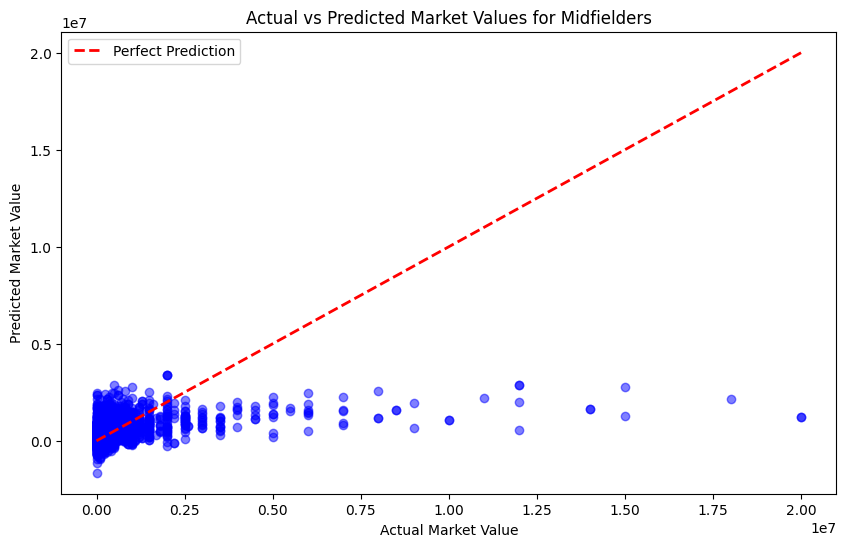

In [43]:
positions_to_check = ['AMF', 'DMF', 'RCMF', 'LDMF', 'RDMF', 'LCMF']

df['IsMidfielder'] = df['Position'].apply(lambda x: 1 if isinstance(x, str) and any(pos in x for pos in positions_to_check) else 0) 

# This filters the IsGoalkeeper column so that it only uses the 1s so only if its says its a 'Gk'
midfielder_data = df[df['IsMidfielder'] == 1] 

features = ['Age', 'Height', 'Weight', 'Minutes played', 'Matches played', 'Yellow cards', 'Third assists per 90', 'Second assists per 90', 
            'Assists', 'xG', 'xA', 'Goals', 'Accurate progressive passes, %', 'Progressive passes per 90', 'Deep completed crosses per 90',
            'Assists per 90', 'Crosses per 90', 'Accurate crosses, %', 'Crosses from left flank per 90', 'Accurate crosses from left flank, %',
            'Crosses from right flank per 90', 'Accurate crosses from right flank, %', 'Crosses to goalie box per 90', 'Fouls suffered per 90', 
            'Passes per 90', 'Accurate passes, %', 'Forward passes per 90', 'Accurate forward passes, %', 'Back passes per 90', 'Accurate back passes, %',
            'Lateral passes per 90', 'Accurate lateral passes, %', 'Short / medium passes per 90', 'Accurate short / medium passes, %', 'Long passes per 90',
            'Accurate long passes, %', 'Average pass length, m', 'Average long pass length, m', 'xA per 90', 'Shot assists per 90', 'Second assists per 90',
            'Third assists per 90', 'Smart passes per 90', 'Accurate smart passes, %', 'Key passes per 90', 'Passes to final third per 90',
            'Accurate passes to final third, %', 'Passes to penalty area per 90', 'Accurate passes to penalty area, %', 'Through passes per 90',
            'Accurate through passes, %', 'Deep completions per 90', 'Deep completed crosses per 90', 'Progressive passes per 90',
            'Accurate progressive passes, %']

X_midfielder = midfielder_data[features]
y_midfielder = midfielder_data['Market value']

imputer = SimpleImputer(strategy='mean')
X_midfielder_imputed = imputer.fit_transform(X_midfielder)

X_train, X_test, y_train, y_test = train_test_split(X_midfielder_imputed, y_midfielder, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE score for this model: {mse}')
print(f'R2 score for this model: {r2}')

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
plt.title('Actual vs Predicted Market Values for Midfielders')
plt.xlabel('Actual Market Value')
plt.ylabel('Predicted Market Value')
plt.legend()
plt.show()

##### Linear Regression of Market Value vs Predicted Market Value for Defenders:

MSE score for this model: 1696389246167.3796
R2 score for this model: 0.05178938236093722


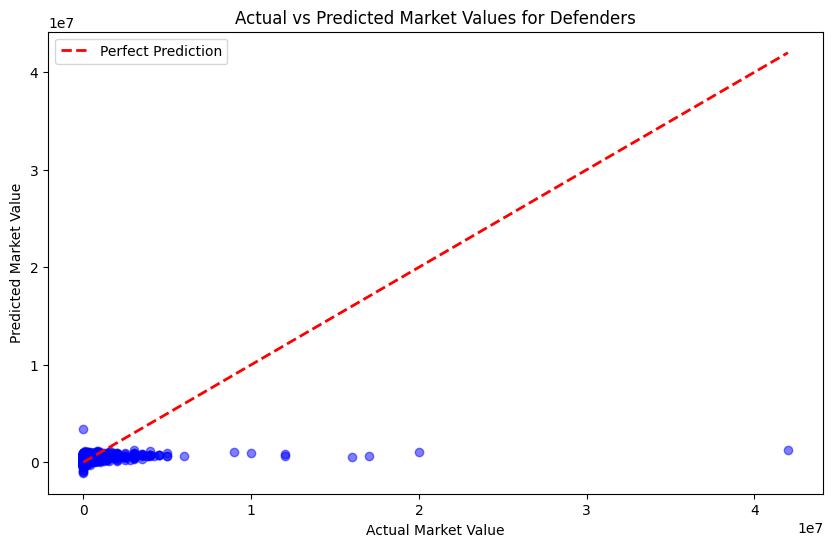

In [44]:
positions_to_check = ['CB', 'RCB', 'LCB', 'LB', 'RB', 'LWB', 'RWB']

df['IsDefender'] = df['Position'].apply(lambda x: 1 if isinstance(x, str) and any(pos in x for pos in positions_to_check) else 0) 

# This filters the IsGoalkeeper column so that it only uses the 1s so only if its says its a 'Gk'
defender_data = df[df['IsDefender'] == 1] 

features = ['Age', 'Height', 'Weight', 'Minutes played', 'Matches played', 'Prevented goals per 90', 'Prevented goals', 'xG against per 90',
            'xG against', 'Shots against', 'Red cards per 90', 'Red cards', 'Yellow cards per 90', 'Fouls per 90', 'PAdj Interceptions', 
            'Interceptions per 90', 'Shots blocked per 90', 'PAdj Sliding tackles', 'Sliding tackles per 90', 'Aerial duels won, %',
            'Aerial duels per 90', 'Defensive duels won, %', 'Defensive duels per 90', 'Successful defensive actions per 90', 'Duels won, %', 
            'Duels per 90']

X_defender = defender_data[features]
y_defender = defender_data['Market value']

imputer = SimpleImputer(strategy='mean')
X_defender_imputed = imputer.fit_transform(X_defender)

X_train, X_test, y_train, y_test = train_test_split(X_defender_imputed, y_defender, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE score for this model: {mse}')
print(f'R2 score for this model: {r2}')

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
plt.title('Actual vs Predicted Market Values for Defenders')
plt.xlabel('Actual Market Value')
plt.ylabel('Predicted Market Value')
plt.legend()
plt.show()

#### Logistic regression

In [45]:
logreg_model = LogisticRegression() #making a logistic regression model 
logreg_model.fit(X_train, y_train) #Fitting
logreg_predictions = logreg_model.predict(X_test) #Predicting

logreg_score = logreg_model.score(X_test, y_test)

overall_accuracy = accuracy_score(y_test, logreg_predictions)

# Calculate macro-averaged precision, recall, and F1-score
precision, recall, f1, _ = precision_recall_fscore_support(y_test, logreg_predictions, average='macro')

print("\nOverall Model Performance:")
print("Overall Accuracy:", overall_accuracy)
print("Macro-Averaged Precision:", precision)
print("Macro-Averaged Recall:", recall)
print("Macro-Averaged F1-score:", f1)


Overall Model Performance:
Overall Accuracy: 0.16116870876531575
Macro-Averaged Precision: 0.007848426247252282
Macro-Averaged Recall: 0.022108309028126993
Macro-Averaged F1-score: 0.010123745046302923


c:\Users\emilp\anaconda3\envs\block_b\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\emilp\anaconda3\envs\block_b\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


#### Tree-based model

A General Random Forest Classifier for the 'Goals' column.

In [46]:
X = df2.drop(['Goals'], axis='columns')
y = df2['Goals']

X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size = 0.30) 

# creating a RF classifier 
rf = RandomForestClassifier(n_estimators = 100)   
  
# Training the model on the training dataset 
rf.fit(X_train, y_train) 
  
# performing predictions on the test dataset 
y_pred = rf.predict(X_test) 
  
# metrics are used to find accuracy or error 
from sklearn import metrics   
print() 
  
# using metrics module for accuracy calculation 
print("ACCURACY OF THE MODEL: ", metrics.accuracy_score(y_test, y_pred)) 
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


ACCURACY OF THE MODEL:  0.9181616609554525

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2204
           1       0.98      1.00      0.99      1039
           2       0.93      0.97      0.95       594
           3       0.89      0.90      0.90       356
           4       0.77      0.86      0.81       209
           5       0.79      0.65      0.71       149
           6       0.53      0.64      0.58       100
           7       0.44      0.44      0.44        80
           8       0.40      0.27      0.32        60
           9       0.31      0.36      0.34        44
          10       0.00      0.00      0.00        18
          11       0.29      0.19      0.23        21
          12       0.06      0.05      0.05        20
          13       0.36      0.27      0.31        15
          14       0.14      0.08      0.10        13
          15       0.00      0.00      0.00        12
          16 

c:\Users\emilp\anaconda3\envs\block_b\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\emilp\anaconda3\envs\block_b\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\emilp\anaconda3\envs\block_b\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


A Random Forest Classifier for Goalkeepers and their features.

In [47]:
df['IsGoalKeeper'] = df['Position'].apply(lambda x: 1 if isinstance(x, str) and 'GK' in x else 0) 

# This filters the IsGoalkeeper column so that it only uses the 1s so only if its says its a 'Gk'
goalkeeper_data = df[df['IsGoalKeeper'] == 1] 

features = ['Age', 'Clean sheets', 'Prevented goals', 'Prevented goals per 90', 'Save rate, %', 'xG against', 'Conceded goals', 
            'Conceded goals per 90', 'Back passes received as GK per 90', 'xG against per 90', 'Height', 'Weight', 'Minutes played', 
            'Matches played', 'Duels per 90', 'Duels won, %', 'Successful defensive actions per 90', 'Yellow cards', 'Shots against', 
            'Shots against per 90']

X = goalkeeper_data[features]
y = goalkeeper_data['IsGoalKeeper']

imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size = 0.30) 

# creating a RF classifier 
rf = RandomForestClassifier(n_estimators = 100)   
  
# Training the model on the training dataset 
rf.fit(X_train, y_train) 
  
# performing predictions on the test dataset 
y_pred = rf.predict(X_test) 
  
# metrics are used to find accuracy or error 
from sklearn import metrics   
print() 
  
# using metrics module for accuracy calculation 
print("ACCURACY OF THE MODEL: ", metrics.accuracy_score(y_test, y_pred)) 
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


ACCURACY OF THE MODEL:  1.0

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       384

    accuracy                           1.00       384
   macro avg       1.00      1.00      1.00       384
weighted avg       1.00      1.00      1.00       384



As you can see if I include multiple features that pertain to the selected position the accuracy score is the very best it can be.

#### Gradient Boosting Trees

In [48]:
X = df2.drop(['Goals'], axis=1)
y = df2['Goals']

# Encode string class values as integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(y)
encoded_y = label_encoder.transform(y)
test_size = 0.33

# Diving into training and testing sets
x_train, x_test, y_train, y_test = model_selection.train_test_split(X, encoded_y, test_size=test_size, random_state=42)

# Fitting the model in
model = xgboost.XGBClassifier()
model.fit(x_train, y_train)
print(model)

# make predictions for test data
y_pred = model.predict(x_test)
predictions = [round(value) for value in y_pred]

# evaluate predictions
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)
Accuracy: 0.9620670698185816


In [96]:
X = df2.drop(['Goals'], axis=1)
y = df2['Goals']

imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

scaler = StandardScaler()
X_imputed_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X.columns)

# Split data into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2)

gb = GradientBoostingRegressor(max_depth=4, 
            n_estimators=200,
            random_state=2)
# Fit gb to the training set
gb.fit(X_train, y_train)

# Predict test set labels
y_pred = gb.predict(X_test)

# Compute MSE
mse_test = MSE(y_test, y_pred)

# Compute RMSE
rmse_test_gb = mse_test**(1/2)

# Print RMSE
print('Test set RMSE of gb: {:.3f}'.format(rmse_test_gb))

Test set RMSE of gb: 0.130


#### Unsupervised learning with K-Means

                   Goals   Assists
cluster_labels                    
0               8.732054  3.101485
1               2.462991  1.766239
2               0.273200  0.324951


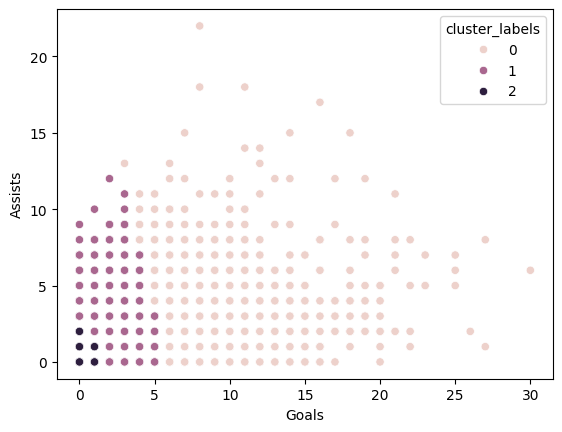

                   Goals   Assists      Height    Weight        xG        xA
cluster_labels                                                              
0               1.886222  1.188434  181.307716  70.48671  1.976488  1.276920
1               1.343922  0.820160    0.000000   0.05903  1.334877  0.857171


In [50]:
# Set seed for reproducibility
np.random.seed(42)

# Convert 'Goals' and 'Assists' to float
df2[['Goals', 'Assists']] = df2[['Goals', 'Assists']].astype(float)

# Perform k-means clustering
features = df2[['Goals', 'Assists']]
num_clusters = 3
cluster_centers, _ = kmeans(features, num_clusters)

# Assign cluster labels
df2['cluster_labels'], _ = vq(features, cluster_centers)

# Display cluster centers
cluster_means = df2.groupby('cluster_labels').mean()[['Goals', 'Assists']]
print(cluster_means)

# Visualize clusters
sns.scatterplot(x='Goals', y='Assists', hue='cluster_labels', data=df2)
plt.show()

scaled_features = ['Goals', 'Assists', 'Height', 'Weight', 'xG', 'xA']

# Create centroids with kmeans for 2 clusters
cluster_centers,_ = kmeans(df[scaled_features], 2)

# Assign cluster labels and print cluster centers
df['cluster_labels'], _ = vq(df[scaled_features], cluster_centers)
print(df.groupby('cluster_labels')[scaled_features].mean())


### --------------------------------------------------------------------------------------------------------------------------------------------------

<span style="color:red; font-size:17pt"> This marks the start of the final part of my template and everything leading up to the final model plays a part in the story telling.</span>

### Subject of final model:  

##### The subject for my model and the business problem to solve will be how to improve the Goalkeepers(GK) in NAC Breda. I will compare NAC Goalkeepers to other GK's of the same level/league and see what they have to do to improve and perform at a higher level. Using my chosen model, the linear regression, we can identify the key features that are needed to actually improve and the features that other GK's do better in. Plugging in the chosen features it will predict the accuracy of the features and we will be able to tell if they are areas that need to be worked on. I also created a score that combines a number of different features together and therefore be able to rank them.



##### Comparing Goalkeepers from NAC Breda to other clubs of the same level to see what they need to improve on to get to higher levels.  

##### First of all, in order to measure goalkeepers, I created a quantifiable score to rate them and pit them against NAC Breda. I call it the GK Score. It combines key features such as Clean sheets, prevented goals, conceded goals, save rate %, prevented goals per 90 and conceded goals per 90. And with those features it creates a score that we can go off of.  

#### How does it work: 

##### Like I said, it combines the data from some of the columns from the dataset that are relevant to the situation using the weighted scoring method. I fine tuned it to make it just for Goalkeepers because of the used stats. I assign weights to the different stats, that dictates the importance of each stat when calculating the Custom score, and as seen I have assigned equal importance across all of the metrics. For conceded goals and conceded goals per 90, you might see that the weights are negative. The reason for that is if a goalkeeper has an increase in conceded goals then as a result the overall score should lower itself since that is something negative in football and something to be avoided. So how that works, if a goalkeeper has less conceded goals, then their score will go up accordingly. Then I used a scaler to normalize the score and have it be in a range from 0 to 1 so that it is easy to understand. And that's how the score works. Let's explore some more. 

##### These are the top 10 goalkeepers with the highest GK Scores:

In [69]:
# Stats used to make the custom score and assigning the appropriate weights for the stats, which have been evenly distributed so they all hold the same weight
# Conceded goals and conceded goals per 90 are both negative because an increase in conceded goals is not supposed to be good for the score, it is supposed to decrease it
weights = {'Clean sheets': 0.20, 'Prevented goals': 0.20, 'Conceded goals': -0.20, 'Save rate, %': 0.20, 'Prevented goals per 90': 0.20, 'Conceded goals per 90': -0.20}

# Using a mixmaxscaler as the scaler for this
scaler = MinMaxScaler()

# Scale each column to be between 0 and 1
scaled_features = scaler.fit_transform(df[['Clean sheets', 'Prevented goals', 'Conceded goals', 'Save rate, %', 'Prevented goals per 90', 'Conceded goals per 90']])

# Assign weights to scaled columns
df['GK Scoree'] = (scaled_features[:, 0] * weights['Clean sheets'] +
                  scaled_features[:, 1] * weights['Prevented goals'] +
                  scaled_features[:, 2] * weights['Conceded goals'] +
                  scaled_features[:, 3] * weights['Save rate, %'] +
                  scaled_features[:, 4] * weights['Prevented goals per 90'] +
                  scaled_features[:, 5] * weights['Conceded goals per 90'])

# Normalizing the GK Score so that it give a range from 0 to 1 instead of -1.20 to 1.20
df['GK Score'] = scaler.fit_transform(df[['GK Scoree']])

# Grouping only GK's together along with the name and their score
gk_players = df[df['IsGoalkeeper'] == 1][['Player', 'GK Scoree', 'GK Score']]
top_10_gk = df.sort_values(by='GK Score', ascending=False).head(10)

print(top_10_gk[['Player', 'Team', 'GK Score']])


                  Player           Team  GK Score
11943     V. Černiauskas      Panevėžys  1.000000
14702        M. Vidovšek       Olimpija  0.981879
10681       A. Fulignati      Catanzaro  0.958201
6686         A. Brignoli  Panathinaikos  0.949469
11713        J. Nerugals            RFS  0.944846
9696      S. Pizzignacco    FeralpiSalò  0.918419
15571  José Antonio Caro         Burgos  0.901684
1350     Gustavo Busatto     CSKA Sofia  0.891359
6683     G. Athanasiadis     AEK Athens  0.891131
2072                Vaná           Aris  0.885337


#### I will go more in detail about the GK Scores and use them to explain the final model, but that comes a little later, for now comes the correlation analysis, feature selection, evualuation and how I made it more accurate.

#### Correlation Analysis and Feature Selection

Correlation Coefficients:
Clean sheets              0.805827
Prevented goals           0.503129
Conceded goals            0.549400
Save rate, %              0.822927
Prevented goals per 90    0.466930
Conceded goals per 90    -0.508086
dtype: float64


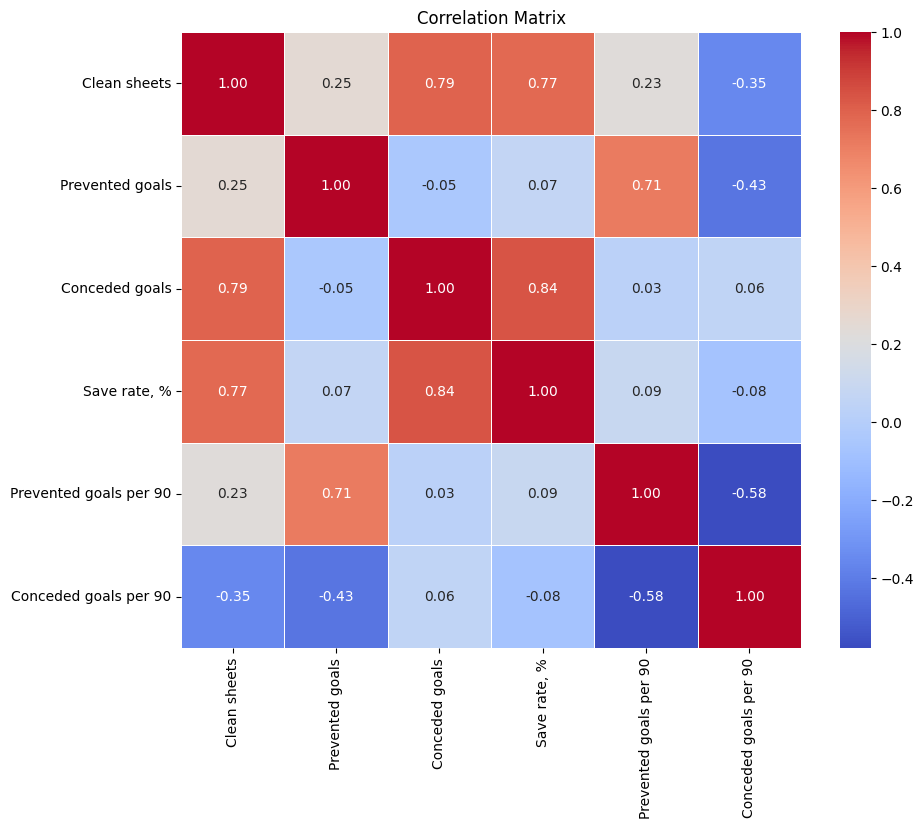

In [71]:
features = df[['Clean sheets', 'Prevented goals', 'Conceded goals', 'Save rate, %', 'Prevented goals per 90', 'Conceded goals per 90']]
customscore = df['GK Score']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(features, customscore, test_size=0.2, random_state=42)

# Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Linear Regression Model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Standardized Coefficients
standardized_coefficients = pd.DataFrame({'Feature': features.columns, 'Standardized Coefficient': model.coef_})

# Model Evaluation
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

correlation_matrix = features.corr()
correlation_with_custom_score = features.corrwith(customscore)

# Print Correlation Coefficients
print("Correlation Coefficients:")
print(correlation_with_custom_score)

# Visualize Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

#### What this indicates is that when there is an increase in clean sheets, there is an increase in the GK Score. When there is an increase in prevented goals, there is an increase in GK Score. When there is a decrease in conceded goals per 90, there is an increase in GK Score. Now these are all obvious things. Of course when you let less goals in to the net the higher the GK score is going to be, that is common knowledge and basic logic. That is why I delve deeper into this topic for my final model. Stat tuned for that. 

In [ ]:
from sklearn.feature_selection import RFE

# Features and custom score for all goalkeepers
features = df[['Clean sheets', 'Prevented goals', 'Conceded goals', 'Save rate, %', 'Prevented goals per 90', 'Conceded goals per 90']]
customscore = df['GK Score']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(features, customscore, test_size=0.2, random_state=42)

# Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Linear Regression Model for Feature Selection
model_for_selection = LinearRegression()

# RFE
selector = RFE(model_for_selection, n_features_to_select=3)  # Select 3 features, adjust as needed
selector = selector.fit(X_train_scaled, y_train)

# Selected Features
selected_features = features.columns[selector.support_]

# Updated Features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# Linear Regression Model with Selected Features
model_selected = LinearRegression()
model_selected.fit(X_train_selected, y_train)

# Model Evaluation for Selected Features
y_pred_selected = model_selected.predict(X_test_selected)
mse_selected = mean_squared_error(y_test, y_pred_selected)
r2_selected = r2_score(y_test, y_pred_selected)
mae_selected = mean_absolute_error(y_test, y_pred_selected)

# Display Results
print("Selected Features Model Coefficients:")
print(pd.DataFrame({'Feature': selected_features, 'Coefficient': model_selected.coef_}))

print("\nModel with Selected Features Evaluation:")
print(f"MSE: {mse_selected}, R^2: {r2_selected}, MAE: {mae_selected}")


Selected Features Model Coefficients:
          Feature  Coefficient
0    Clean sheets     0.023093
1  Conceded goals    -0.006490
2    Save rate, %     0.002963

Model with Selected Features Evaluation:
MSE: 0.0001455429958289953, R^2: 0.9061964700387575, MAE: 0.0019889091371997425


##### This highlights the most important features used, like I said I will delve deeper into this later on.

✍️ I chose the features above because they have the most importance in the given cotext. They work the best to calculate an accurate GK Score.

### Evaluating the performance of the model

In the following subsection include your Python code on how you evaluated your chosen model(s). This is related to the sufficient criteria of ILO 5.0. 

In [56]:
# Features and custom score for all goalkeepers
features = df[['Clean sheets', 'Prevented goals', 'Conceded goals', 'Save rate, %', 'Prevented goals per 90', 'Conceded goals per 90']]
customscore = df['GK Score']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(features, customscore, test_size=0.2, random_state=42)

# Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Linear Regression Model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Standardized Coefficients
standardized_coefficients = pd.DataFrame({'Feature': features.columns, 'Standardized Coefficient': model.coef_})

# Model Evaluation
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print R-squared and MSE
print(f'\nMean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')
print(f'R-squared: {r2}')


Mean Squared Error: 1.448465735486122e-30
Mean Absolute Error: 3.5313358176246044e-16
R-squared: 1.0


As it can be seen, the scores given are really good, near perfect actually. There is not much that can be improved with this score but with the score being this good there are risks of overfitting. Let's check for that.

Checking with cross validation:

In [57]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
average = np.mean(np.abs(scores))
print("Accuracy for each fold:")
average

Accuracy for each fold:


1.2049558502771587e-30

Let's also check the training set performance:

In [58]:
y_train_pred = model.predict(X_train_scaled)
train_mse = mean_squared_error(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# print results
print(f'Training Set Mean Squared Error: {train_mse}')
print(f'Training Set Mean Absolute Error: {train_mae}')
print(f'Training Set R-squared: {train_r2}')

Training Set Mean Squared Error: 1.539335631200482e-30
Training Set Mean Absolute Error: 3.4949300544032513e-16
Training Set R-squared: 1.0


And also for the testing set performance:

In [59]:
y_test_pred = model.predict(X_test_scaled)
test_mse = mean_squared_error(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Print the results
print(f'Test Set Mean Squared Error: {test_mse}')
print(f'Test Set Mean Absolute Error: {test_mae}')
print(f'Test Set R-squared: {test_r2}')

Test Set Mean Squared Error: 1.448465735486122e-30
Test Set Mean Absolute Error: 3.5313358176246044e-16
Test Set R-squared: 1.0


As you can see, the scores for every test we did came out really good and the fears of overfitting have gone.

### Improving the performance of the model

In the following subsection include your Python code on how you improved your chosen model(s). This is related to the good criteria of ILO 5.0.  

Of course, the model I used earlier can't hardly be improved, that's just how it's designed. So I will use a different objective for the improving of the model part. This model tries to predict number of goals scored based on some metrics only for attacking positions. This is the model without applying anything:

In [60]:
positions_to_check = ['RW', 'AMF', 'CF', 'LWF', 'RWF', 'LW']

df['IsAttacker'] = df['Position'].apply(lambda x: 1 if isinstance(x, str) and any(pos in x for pos in positions_to_check) else 0) 

# This filters the IsGoalkeeper column so that it only uses the 1s so only if its says its a 'Gk'
attacker_data = df[df['IsAttacker'] == 1] 

features = ['Age', 'Height', 'Weight', 'Minutes played', 'Matches played', 'Yellow cards',
            'Penalties taken', 'Penalty conversion, %', 'Free kicks per 90', 'Direct free kicks per 90', 'Third assists per 90', 
            'Second assists per 90', 'Shot assists per 90', 'xA per 90']
            
X_attacker = attacker_data[features]
y_attacker = attacker_data['Goals']


imputer = SimpleImputer(strategy='mean')
X_attacker_imputed = imputer.fit_transform(X_attacker)

X_train, X_test, y_train, y_test = train_test_split(X_attacker_imputed, y_attacker, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE score for this model: {mse}')
print(f'R2 score for this model: {r2}')

MSE score for this model: 4.854112285593278
R2 score for this model: 0.5776454470006878


And this is the second model with improving methods applied to it:

In [61]:
positions_to_check = ['RW', 'AMF', 'CF', 'LWF', 'RWF', 'LW']

df['IsAttacker'] = df['Position'].apply(lambda x: 1 if isinstance(x, str) and any(pos in x for pos in positions_to_check) else 0) 

# This filters the IsGoalkeeper column so that it only uses the 1s so only if its says its a 'Gk'
attacker_data = df[df['IsAttacker'] == 1] 

features = ['Age', 'Height', 'Weight', 'Minutes played', 'Matches played', 'Yellow cards',
            'Penalties taken', 'Penalty conversion, %', 'Free kicks per 90', 'Direct free kicks per 90', 'Third assists per 90', 
            'Second assists per 90', 'Shot assists per 90', 'xA per 90', 'Successful dribbles, %', 'Dribbles per 90', 'Goal conversion, %',
            'Shots on target, %', 'Shots on target, %', 'Shots per 90', 'Shots', 'Head goals per 90', 'Head goals', 'xG per 90', 
            'Non-penalty goals per 90', 'Non-penalty goals', 'Goals per 90', 'Successful attacking actions per 90', 'xG', 'xA', 
            'Progressive runs per 90', 'Received passes per 90', 'Received long passes per 90', 'Fouls suffered per 90', 'Passes per 90', 
            'Accurate passes, %']
            
X_attacker = attacker_data[features]
y_attacker = attacker_data['Goals']

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_attacker)

imputer = SimpleImputer(strategy='mean')
X_attacker_imputed = imputer.fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(X_attacker_imputed, y_attacker, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Define the parameter grid
param_grid = {
    'fit_intercept': [True, False],
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring='neg_mean_squared_error', cv=5)

# Fit GridSearchCV on training data
grid_search.fit(X_train, y_train)

# Get the best parameters
best_params = grid_search.best_params_

# Print the best parameters
print("Best parameters:", best_params)

print(f'MSE score for this model: {mse}')
print(f'R2 score for this model: {r2}')

Best parameters: {'fit_intercept': True}
MSE score for this model: 0.07098604249893656
R2 score for this model: 0.9938235301359197


✍️ I improved my model by adding a MinMax scaler to the model so that the ranges of the features used arent influencing the score in a negative way and normalizes everything. I also used hyperparameter tuning, specifically GridSearchCV, it found that the best combination would be for fit_intercept to be true. But the thing that improved the score the most was adding more features and carefully choosing the features that would add the most to the overall score and performance of the model.

#### Now we're back with the final bit of EDA to do for the final model using the custom GK Score that I made earlier. Once again I will show the top ten keepers with the highest scores:

In [68]:
# Grouping only GK's together along with the name and their score
gk_players = df[df['IsGoalkeeper'] == 1][['Player', 'GK Scoree', 'GK Score']]
top_10_gk = df.sort_values(by='GK Score', ascending=False).head(10)

print(top_10_gk[['Player', 'Team', 'GK Score']])

                  Player           Team  GK Score
11943     V. Černiauskas      Panevėžys  1.000000
14702        M. Vidovšek       Olimpija  0.996372
8675            S. Golan  Hapoel Hadera  0.964037
10681       A. Fulignati      Catanzaro  0.960032
11713        J. Nerugals            RFS  0.955191
6686         A. Brignoli  Panathinaikos  0.954035
9696      S. Pizzignacco    FeralpiSalò  0.927221
8654           R. Kadoch           Aris  0.927019
15571  José Antonio Caro         Burgos  0.918398
14423            A. Vlad  FCS Bucureşti  0.917064


##### Now lets take a look at the scores for NAC Breda's only goalkeeper:

In [62]:
target_club = 'NAC Breda'

# Filter the DataFrame to include only goalkeepers from the specific club
gk_data_specific_club = df[(df['IsGoalkeeper'] == 1) & (df['Team'] == target_club)]

# Check if there are goalkeepers from the specified club
top_10_gk_specific_club = gk_data_specific_club.sort_values(by='GK Score', ascending=False).head(10)

# Display the selected club along with name and GK Score
print(top_10_gk_specific_club[['Player', 'Team', 'GK Score']])

            Player       Team  GK Score
11283  R. Kortsmit  NAC Breda  0.401693


##### And how does he compare to other keepers of similar level (from the same league):

In [63]:
# Chosen clubs for the comparison 
target_clubs = ['Willem II', 'ADO Den Haag', 'Cambuur', 'Groningen', 'Eindhoven', 'De Graafschap', 'VVV Venlo', 'NAC Breda']

# Filter the DataFrame to include only goalkeepers based on 'team' and or 'team within selected timeframe'
gk_data_filtered = df[
    (df['IsGoalkeeper'] == 1) &
    (df['Team'].isin(target_clubs) | df['Team within selected timeframe'].isin(target_clubs))
]

# Check if there are goalkeepers from the specified criteria
top_10_gk_filtered = gk_data_filtered.sort_values(by='GK Score', ascending=False).head(20)

# Display the top 10 goalkeepers from the specified criteria
print(top_10_gk_filtered[['Player', 'Team', 'GK Score']])

                Player             Team  GK Score
11333      L. Koopmans  Fortuna Sittard  0.720782
3899     João Virginia          Everton  0.667693
11241       K. Lamprou        Feyenoord  0.661287
6781        S. Stevens     ADO Den Haag  0.608131
11199  E. van der Gouw    Zulte-Waregem  0.590938
11303          L. Zima      Petrolul 52  0.586970
3947   P. Leeuwenburgh             Aris  0.574448
11286         J. Smits        Willem II  0.573760
11143       S. Stevens      Dewa United  0.546210
11155        H. Jurjus        Groningen  0.519367
11182       H. Wentges     ADO Den Haag  0.512074
3997         R. Ruiter             Aris  0.452913
11283      R. Kortsmit        NAC Breda  0.401693
11169        T. Jansen    De Graafschap  0.374861
3863        M. Verrips        Groningen  0.374347


##### As we can see, NAC Bredas goalkeeper is not doing so well in the rankings, sitting at two positions from the bottom.  

##### For the last comparison, how does NACs keeper compare to the teams that are one level above, in the Eredivise, the highest level of proffessional football in the dutch league. This is exactly where NAC should be aiming for.  

##### Comparison of Eredivise team Goalkeepers vs NAC Bredas keeper:

In [ ]:
# Chosen clubs for the comparison
target_clubs = ['PSV', 'Ajax', 'Feyenoord', 'NAC Breda', 'Twente', 'Heerenveen', 'Utrecht']

# Filter the DataFrame to include only goalkeepers based on 'team' and or 'team within selected timeframe'
gk_data_filtered = df[
    (df['IsGoalkeeper'] == 1) &
    (df['Team'].isin(target_clubs) | df['Team within selected timeframe'].isin(target_clubs))
]

# Check if there are goalkeepers from the specified criteria
top_10_gk_filtered = gk_data_filtered.sort_values(by='GK Score', ascending=False).head(20)

# Display the top 10 goalkeepers from the specified criteria
print(top_10_gk_filtered[['Player', 'Team', 'GK Score']])

                 Player        Team  GK Score
3763      L. Unnerstall      Twente  0.848799
3681          J. Bijlow   Feyenoord  0.770893
3722         A. Noppert  Heerenveen  0.716209
11097     F. de Keijzer     Utrecht  0.675140
11241        K. Lamprou   Feyenoord  0.661287
4027         R. Pasveer        Ajax  0.617738
3686           G. Rulli        Ajax  0.599512
3684         W. Benítez         PSV  0.573712
11392        T. Nijhuis     Utrecht  0.568312
3748         J. Drommel         PSV  0.561313
3841   T. Wellenreuther   Feyenoord  0.555266
3752          V. Barkas     Utrecht  0.544164
11288       K. Peersman         PSV  0.443079
11380        C. Raatsie     Utrecht  0.433312
3976            X. Mous        Aris  0.406472
11283       R. Kortsmit   NAC Breda  0.401693


##### As expected, NAC's keeper landed at dead last amongst the Eredivise clubs. There are some clear things to improve on.

##### Now, based on the used stats for the GK Score, how much better are the keepers that sit above the NAC Breda keeper (that are from the same league) and what should he improve on:

In [ ]:
# List of specific players I want to include
selected_players = ['K. Lamprou', 'João Virginia', 'S. Stevens', 'E. van der Gouw', 'L. Zima ', 'J. Smits', 'R. Kortsmit']

# Checking if player is part of the selected players
selected_rows = df['Player'].isin(selected_players)

# Printing out the selected columns
df.loc[selected_rows, ['Player', 'Team', 'Clean sheets', 'Prevented goals', 'Conceded goals', 'Save rate, %', 'Prevented goals per 90', 'Conceded goals per 90']]

,Player,Team,Clean sheets,Prevented goals,Conceded goals,"Save rate, %",Prevented goals per 90,Conceded goals per 90
3899,João Virginia,Everton,4.0,5.17,28.0,72.82,0.280,1.51
6781,S. Stevens,ADO Den Haag,1.0,0.56,10.0,61.54,0.084,1.50
11143,S. Stevens,Dewa United,2.0,-1.27,23.0,65.67,-0.085,1.54
11199,E. van der Gouw,Zulte-Waregem,6.0,0.55,39.0,70.90,0.016,1.17
11241,K. Lamprou,Feyenoord,10.0,-0.69,28.0,70.53,-0.024,0.97
11283,R. Kortsmit,NAC Breda,6.0,-6.33,60.0,64.07,-0.165,1.57
11286,J. Smits,Willem II,3.0,-2.76,11.0,59.26,-0.257,1.02


##### The results are mixed. In terms of clean sheets, Kortsmit is actually doing pretty well against the others. But the prevented goals and prevented goals per 90 definately need a lot of working on since it is the lowest on the list. Same case with Conceded goals, it is by far the highest in the list for the NAC keeper, which is something that needs fixing. As for save rate %, this stat isn't so bad. And for conceded goals per 90 it once again looks to be quite high but the other keepers more or less have a similar score so in comparison it is not so bad.  

##### Now for the final look and model. I will use a linear regression model to predict and caclulate what the stats need to be focused on to be improve the GK Score and ergo improving as a player. I will explain it in the following cells.

### Choose the best model

In the following subsection reflect on the most appropriate machine learning model. This is related to the excellent criteria of ILO 5.0.  



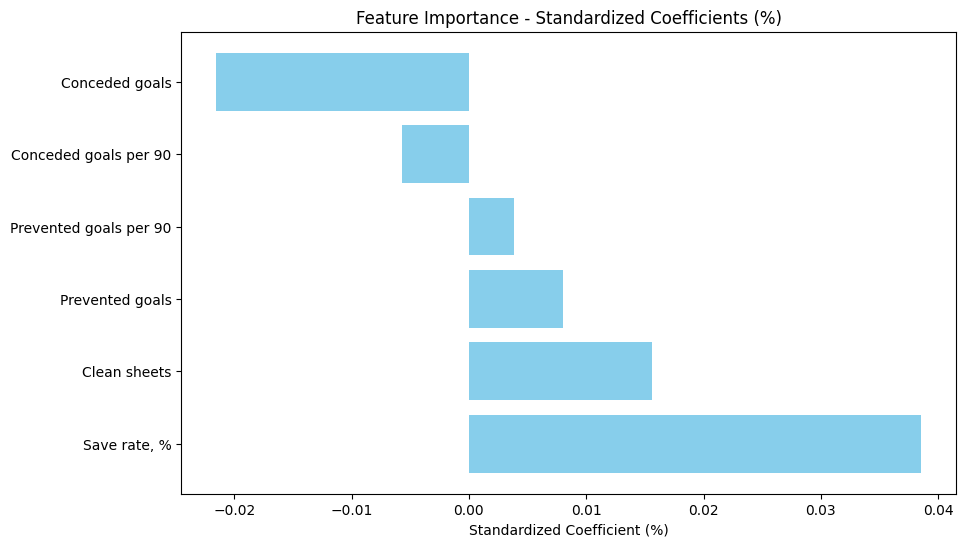

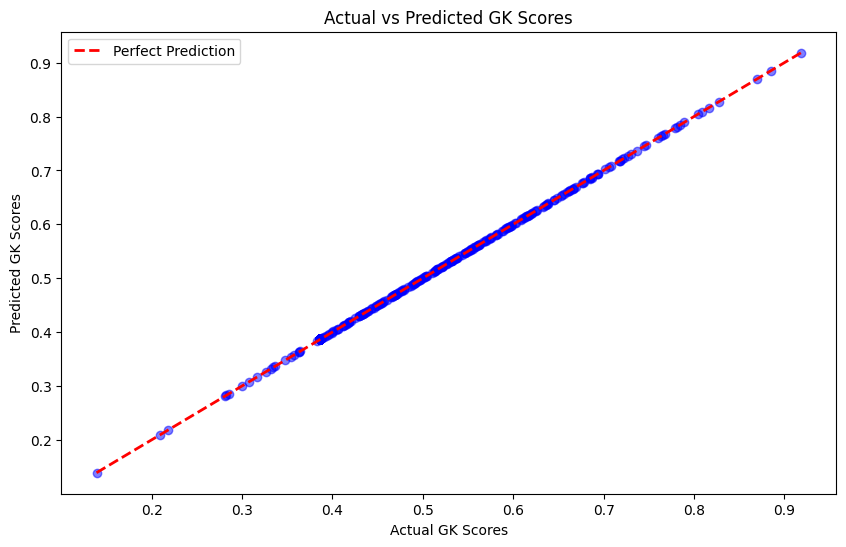


Mean Squared Error: 1.4187189657577117e-30
Mean Absolute Error: 3.5794126669939786e-16
R-squared: 1.0

Stadardized Coefficients:


,Feature,Standardized Coefficient,Standardized Coefficient (%)
3,"Save rate, %",0.038529,3.852887
0,Clean sheets,0.015624,1.562398
1,Prevented goals,0.007991,0.799149
4,Prevented goals per 90,0.003817,0.381734
5,Conceded goals per 90,-0.005746,-0.574601
2,Conceded goals,-0.021534,-2.153364


In [85]:
# Features and custom score for all goalkeepers
features = df[['Clean sheets', 'Prevented goals', 'Conceded goals', 'Save rate, %', 'Prevented goals per 90', 'Conceded goals per 90']]
customscore = df['GK Score']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(features, customscore, test_size=0.2, random_state=42)

# Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Linear Regression Model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Standardized Coefficients
standardized_coefficients = pd.DataFrame({'Feature': features.columns, 'Standardized Coefficient': model.coef_})

standardized_coefficients['Standardized Coefficient (%)'] = standardized_coefficients['Standardized Coefficient'] * 100

standardized_coefficients = standardized_coefficients.sort_values(by='Standardized Coefficient', ascending=False)


# Model Evaluation
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

# Feature Importance Visualization
plt.figure(figsize=(10, 6))
plt.barh(standardized_coefficients['Feature'], standardized_coefficients['Standardized Coefficient'], color='skyblue')
plt.xlabel('Standardized Coefficient (%)')
plt.title('Feature Importance - Standardized Coefficients (%)')
plt.show()

# Linear regression scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
plt.title('Actual vs Predicted GK Scores')
plt.xlabel('Actual GK Scores')
plt.ylabel('Predicted GK Scores')
plt.legend()
plt.show()

# Print R-squared and MSE
print(f'\nMean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')
print(f'R-squared: {r2}')

print('\nStadardized Coefficients:')
standardized_coefficients

#### How this works:

##### We measure this in one-standard-deveation. When there is one-standard-deveation increase in the Clean sheets column, there will be an increase of 1.56% on the GK Score. By adding the standard deveation and mean of the Clean sheets column we can get the one-standard-deveation. Let's calculate how much one-standard-deveation is for the Clean sheets column:


In [94]:
std = df['Clean sheets'].std()
mean = df['Clean sheets'].mean()

onedev = std + mean
print(f'A One-standard-deveation for Clean sheets is equal to {onedev} clean sheets')

A One-standard-deveation for Clean sheets is equal to 1.49042475248585 clean sheets


##### What this means is that when there is an increase of roughly 1.5 clean sheets then the GK Score will go up 1.56%. And also when there is an increase in conceded goals, there will be a decrease of 2.1 % in the GK Score. 

##### This has illustrated just what exact stats to focus on in order for the NAC Keeper to get better. There is a clear need for the NAC Goalkeeper to get better at his game as we saw with the comparisons, how he was lacking at every single one of them, not to be mean to him but the numbers can't lie. If the NAC keeper improves in these statistics, their GK Score will increase, making their performance increase as well which therefore makes their Market value increase, making it a way to predict market value. I provide a better conclusion on my report and give recommendations at the end. 

##### ✍️ The reason for the choosing of the linear regression model out of all the other is because in the context of the GK Score I assumed that a linear combination of features would reasonably capture the relationship with the target, since the linear regression assumes a linear relationship between the input features and the target variable, giving it a more accurate score than other models would. Also the linear regression performed really well, so it was a no-brainer for me.

### Linear Algebra and Calculus

In the following subsection, provide the related evidences for ILO7.0.

### Assignment for "Elementary Operation on Matrices"

This task is associated with the 'Poor' criterion of ILO 7.0. You can find the assignment [here](https://adsai.buas.nl/Study%20Content/Advanced%20Python/AssignElemOpe.html).   

Please provide the related link to the PDF file for Task 1 of assignment on elementary operations on matrices. 

[Link to pdf](https://github.com/BredaUniversityADSAI/2023-24b-fai1-adsai-EmilFox231007/blob/8887e9a932796261c1d4fbdaf5e516042e9975ad/Deliverables/EleOpeMat_231007.pdf)

Please provide your code for Task 2 of assignment on elementary operations on matrices.

#### Compute the transpose of the following matrices

In [ ]:
a = np.array([
    [3, -5],
    [-2, 7]
])

print(np.transpose(a))

[[ 3 -2]
 [-5  7]]


In [ ]:
b = np.array([
    [2, -3, 4],
    [-5, 6, 7],
    [-8, 9, 1]
])
print(np.transpose(b))

[[ 2 -5 -8]
 [-3  6  9]
 [ 4  7  1]]


#### Compute the element-wise product of matrices A and B

In [ ]:
a = np.array([
    [3, 2, -1],
    [-2, 7, 4],
    [1, 6, 8]
])

b = np.array([
    [2, -3, -4],
    [-5, -6, 7],
    [-8, 9, 1]
])

print(np.multiply(a, b))

[[  6  -6   4]
 [ 10 -42  28]
 [ -8  54   8]]


#### Compute the matrix product of matrices A and B

In [ ]:
a = np.array([
    [3, 2, -1],
    [-2, 7, 4],
    [1, 6, 8]
])

b = np.array([
    [2, -3, -4],
    [-5, -6, 7],
    [-8, 9, 1]
])

print(np.dot(a, b))

[[  4 -30   1]
 [-71   0  61]
 [-92  33  46]]


#### Change the order of the matrices and compute the element-wise and matrix products

In [ ]:
a = np.array([
    [3, 2, -1],
    [-2, 7, 4],
    [1, 6, 8]
])

b = np.array([
    [2, -3, -4],
    [-5, -6, 7],
    [-8, 9, 1]
])

print(np.multiply(b, a))

[[  6  -6   4]
 [ 10 -42  28]
 [ -8  54   8]]


In [ ]:
a = np.array([
    [3, 2, -1],
    [-2, 7, 4],
    [1, 6, 8]
])

b = np.array([
    [2, -3, -4],
    [-5, -6, 7],
    [-8, 9, 1]
])

print(np.dot(b, a))

[[  8 -41 -46]
 [  4 -10  37]
 [-41  53  52]]


#### Compute the determinant of the matrices A, B and C

In [ ]:
a = np.array([
    [3, 2, -1],
    [-2, 7, 4],
    [1, 6, 8]
])

print(np.linalg.det(a))

155.00000000000003


In [ ]:
b = np.array([
    [3, -2, 1],
    [2, 7, 6],
    [-1, 4, 8]
])

print(np.linalg.det(b))

155.00000000000003


In [ ]:
c = np.array([
    [1, 3, 5],
    [2, 6, 7],
    [4, 12, 8]
])

print(np.linalg.det(c))

0.0


#### Compute the inverse of matrices A and B

In [ ]:
a = np.array([
    [3, 2],
    [-2, 7]
])

print(np.linalg.inv(a))

[[ 0.28 -0.08]
 [ 0.08  0.12]]


In [ ]:
b = np.array([
    [4, 0],
    [0, 5]
])

print(np.linalg.inv(b))

[[0.25 0.  ]
 [0.   0.2 ]]


#### Verify that A^-1.B^-1 = (BA)^-1

In [ ]:
a = np.array([
    [0.28, -0.08],
    [0.08, 0.12]
])

b = np.array([
    [0.25, 0. ],
    [0., 0.2 ]
])


c = np.multiply(a, b)

a2 = np.array([
    [3, 2],
    [-2, 7]
])

b2 = np.array([
    [4, 0],
    [0, 5]
])

c2 = np.multiply(b2, a2)

c3 = np.linalg.inv(c2)

print(c)
print('')
print(c3)


[[ 0.07  -0.   ]
 [ 0.     0.024]]

[[0.08333333 0.        ]
 [0.         0.02857143]]


### Consider the following matrices and scalars:

In [ ]:
a = np.array([
    [3, 2, -1],
    [-2, 7, 4],
    [1, 6, 8]
])

b = np.array([
    [-1, 2, 3],
    [5, -4, 9],
    [-7, 8, 6]
])

c = np.array([
    [-5, 4, 9],
    [6, 1, 3],
    [7, 2, -8]
])

be = 3
al = 2

#### Use Python and Numpy to verify the following properties (the following multiplications are considered matrix multiplications):

#### (AT)T = A

In [ ]:
a2 = np.transpose(a)

print(np.transpose(a2))
print('')
print(a)

[[ 3  2 -1]
 [-2  7  4]
 [ 1  6  8]]

[[ 3  2 -1]
 [-2  7  4]
 [ 1  6  8]]


#### A + B = B + A

In [ ]:
print(a+b)
print('')
print(b+a)

[[ 2  4  2]
 [ 3  3 13]
 [-6 14 14]]

[[ 2  4  2]
 [ 3  3 13]
 [-6 14 14]]


#### A + (B + C) = (A + B) + C

In [ ]:
print(a + (b + c))
print('')
print((a + b) + c)

[[-3  8 11]
 [ 9  4 16]
 [ 1 16  6]]

[[-3  8 11]
 [ 9  4 16]
 [ 1 16  6]]


#### (A + B)T = AT + BT

In [ ]:
a2 = (a + b)
print(np.transpose(a2))
print('')
a3 = np.transpose(a)
b2 = np.transpose(b)
print(a3 + b2)

[[ 2  3 -6]
 [ 4  3 14]
 [ 2 13 14]]

[[ 2  3 -6]
 [ 4  3 14]
 [ 2 13 14]]


#### AB =! BA

In [ ]:
a2 = np.multiply(a, b)
b2 = np.multiply(b, a)
print(a2)
print('')
print(b2)

[[ -3   4  -3]
 [-10 -28  36]
 [ -7  48  48]]

[[ -3   4  -3]
 [-10 -28  36]
 [ -7  48  48]]


#### A(BC) = (AB)C

In [ ]:
b2 = np.multiply(b, c)
a2 = np.multiply(a, b2)
print(a2)
print('')

a3 = np.multiply(a, b)
c2 = np.multiply(a3, c)
print(c2)

[[  15   16  -27]
 [ -60  -28  108]
 [ -49   96 -384]]

[[  15   16  -27]
 [ -60  -28  108]
 [ -49   96 -384]]


#### A(B + C) = AB + AC

In [ ]:
b2 = (b + c)
a2 = np.multiply(a, b2)
print(a2)
print('')

a3 = np.multiply(a, b)
a4 = np.multiply(a, c)
print(a3 + a4)

[[-18  12 -12]
 [-22 -21  48]
 [  0  60 -16]]

[[-18  12 -12]
 [-22 -21  48]
 [  0  60 -16]]


#### (AB)T = BT AT

In [ ]:
a3 = np.multiply(a, b)
a4 = np.transpose(a3)
print(a4)
print('')

b2 = (np.transpose(b))
a5 = np.transpose(a)
b3 = np.multiply(b2, a5)
print(b3)

[[ -3 -10  -7]
 [  4 -28  48]
 [ -3  36  48]]

[[ -3 -10  -7]
 [  4 -28  48]
 [ -3  36  48]]


#### (AB)^-1 = B^-1 A^-1

In [ ]:
a2 = np.multiply(a, b)
b2 = np.linalg.inv(a2)
print(b2)
print('')

b3 = np.linalg.inv(b)
a3 = np.linalg.inv(a)
a4 = np.multiply(b3, a3)
print(a4)

[[-0.25271471 -0.02764067  0.00493583]
 [ 0.01875617 -0.01357354  0.01135242]
 [-0.0556104   0.00954261  0.01020072]]

[[ 0.36702509  0.03154122 -0.05376344]
 [ 0.22222222 -0.04480287  0.02867384]
 [ 0.02724014 -0.01146953  0.01792115]]


#### (AT)^-1 = (A^-1)T

In [ ]:
a2 = np.transpose(a)
a3 = np.linalg.inv(a2)
print(a3)
print('')

a4 = np.linalg.inv(a)
a5 = np.transpose(a4)
print(a5)

[[ 0.20645161  0.12903226 -0.12258065]
 [-0.14193548  0.16129032 -0.10322581]
 [ 0.09677419 -0.06451613  0.16129032]]

[[ 0.20645161  0.12903226 -0.12258065]
 [-0.14193548  0.16129032 -0.10322581]
 [ 0.09677419 -0.06451613  0.16129032]]


#### (Al + Be)A = Al A + Be A

In [ ]:
a2 = (al + be)
a3 = np.multiply(a2, a)
print(a3)
print('')

a4 = np.multiply(al, a)
a5 = np.multiply(be, a)
print(a4 + a5)

[[ 15  10  -5]
 [-10  35  20]
 [  5  30  40]]

[[ 15  10  -5]
 [-10  35  20]
 [  5  30  40]]


#### Al(A + B) = Al A + Al B

In [ ]:
a2 = np.multiply(al, (a+b))
print(a2)
print('')

a3 = np.multiply(al, a)
a4 = np.multiply(al, b)
print(a3 + a4)

[[  4   8   4]
 [  6   6  26]
 [-12  28  28]]

[[  4   8   4]
 [  6   6  26]
 [-12  28  28]]


#### (Al A)^-1 = Al^-1 A^-1

In [ ]:
a2 = np.multiply(al, a)
print(np.linalg.inv(a2))
print('')

a3 = al**-1
a4 = np.linalg.inv(a)
print(a3 + a4)

[[ 0.10322581 -0.07096774  0.0483871 ]
 [ 0.06451613  0.08064516 -0.03225806]
 [-0.06129032 -0.0516129   0.08064516]]

[[0.70645161 0.35806452 0.59677419]
 [0.62903226 0.66129032 0.43548387]
 [0.37741935 0.39677419 0.66129032]]


### Assignment for  "Linear Regression Model Using Normal Equations"

This task is associated with the ‘Poor' criterion of ILO 7.0. You need to complete the assignment on linear regression using normal equations at the middle of [this page](https://adsai.buas.nl/Study%20Content/Advanced%20Python/6.AdvancedNumPyMatPlotlib.html).  

### LinRegNor tasks

##### Task 1: Solve the following systems of equations using numpy

[1 + 3 + 3 = 9]<br>
[1 + 1 = 10]<br>
[1 - 1 + 1 = 8]<br>

In [ ]:
import numpy as np

In [ ]:
a = np.array([[1, 3, 1], [1, 1, 0], [1, -2, 1]])
b = np.array([9, 10, 8])

x = np.linalg.solve(a, b)
print(f"The solution for this system of equation is '{x}'")
print('')
solution = 1*x[0] + 3*x[1] + 1*x[2]
print(f"Inserting the answers into the firs line of the system of equation: 1x + 3y + 1z we get the answer: '{solution}'")


The solution for this system of equation is '[ 9.8  0.2 -1.4]'

Inserting the answers into the firs line of the system of equation: 1x + 3y + 1z we get the answer: '9.0'


[5 + 6 - 7 + 1 = 8]<br>
[1 + 2 + 3 + 4 = 7]<br>
[1 + 3 = 9]<br>
[1 - 3 = 12]<br>


In [ ]:
a = np.array([[5, 6, -7, 1], [1, 2, 3, 4], [1, 0, 1, 0], [1, -3, 0, 0]])
b = np.array([8, 7, 9, 12])
x = np.linalg.solve(a, b)

print(f"The solution for this system of equation is '{x}'")
print('')
solution = 5*x[0] + 6*x[1] -7*x[2] + 1*x[3]
print(f"Inserting the answers into the firs line of the system of equation: 1x + 3y + 1z we get the answer: '{solution}'")

The solution for this system of equation is '[ 6.8372093  -1.72093023  2.1627907  -0.72093023]'

Inserting the answers into the firs line of the system of equation: 1x + 3y + 1z we get the answer: '8.0'


#### Task 2: Use the following snippet of code to generate data for x and y and find a linear regression model.

[[1.         1.        ]
 [1.         1.44444444]
 [1.         1.88888889]
 [1.         2.33333333]
 [1.         2.77777778]
 [1.         3.22222222]
 [1.         3.66666667]
 [1.         4.11111111]
 [1.         4.55555556]
 [1.         5.        ]]
[[ 5.01874743]
 [ 5.93374689]
 [ 6.75744495]
 [ 7.7332117 ]
 [ 8.60657734]
 [ 9.68966348]
 [10.19807818]
 [11.15315283]
 [12.19994942]
 [12.9324518 ]]

Theta_0: 3.068271319168755
Theta_1: 1.9846770277234353


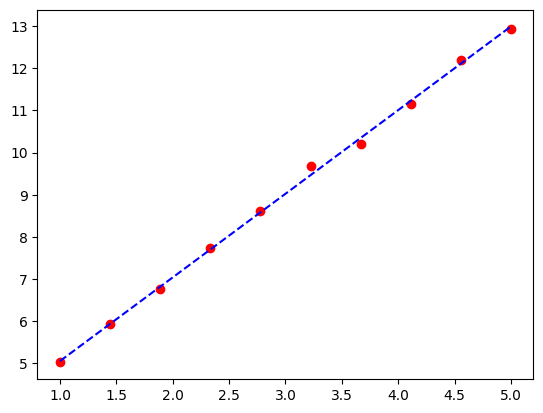

In [ ]:
import matplotlib.pyplot as plt

np.random.seed(1358)

n_sample = 10
x = np.linspace(1, 5, n_sample)
e = 0.1 * np.random.randn(n_sample)

bX = np.ones((n_sample, 1))
X = np.concatenate((bX, np.expand_dims(x, axis=1)), axis=1)

y = 2 * x + 3 + e
Y = np.expand_dims(y, axis=1)

theta = np.linalg.lstsq(X, Y, rcond=None)[0]

plt.scatter(x, y, color='r')
plt.plot(x, theta[0] + theta[1]*x, color='b', linestyle='--', marker='')

print(X)
print(Y)

print(f"\nTheta_0: {theta[0][0]}")
print(f"Theta_1: {theta[1][0]}")

#### Task 3: Use the following snippet of code to generate data for x and y and find a linear regression model.

[[  1.           1.           1.        ]
 [  1.           1.31034483   1.71700357]
 [  1.           1.62068966   2.62663496]
 [  1.           1.93103448   3.72889417]
 [  1.           2.24137931   5.02378121]
 [  1.           2.55172414   6.51129608]
 [  1.           2.86206897   8.19143876]
 [  1.           3.17241379  10.06420927]
 [  1.           3.48275862  12.12960761]
 [  1.           3.79310345  14.38763377]
 [  1.           4.10344828  16.83828775]
 [  1.           4.4137931   19.48156956]
 [  1.           4.72413793  22.31747919]
 [  1.           5.03448276  25.34601665]
 [  1.           5.34482759  28.56718193]
 [  1.           5.65517241  31.98097503]
 [  1.           5.96551724  35.58739596]
 [  1.           6.27586207  39.38644471]
 [  1.           6.5862069   43.37812128]
 [  1.           6.89655172  47.56242568]
 [  1.           7.20689655  51.93935791]
 [  1.           7.51724138  56.50891795]
 [  1.           7.82758621  61.27110583]
 [  1.           8.13793103  66.22

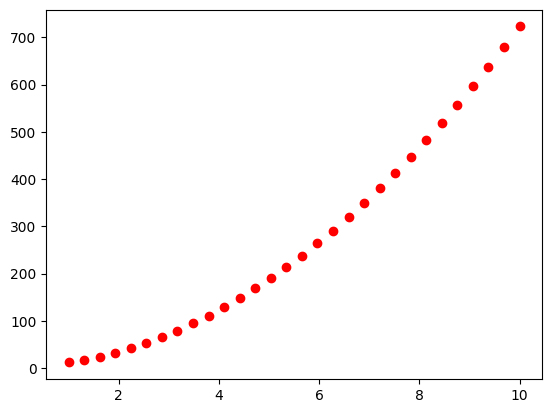

In [ ]:
np.random.seed(1358)

n_sample = 30
x = np.linspace(1, 10, n_sample)
e = 0.2 * np.random.randn(n_sample)

bX = np.ones((n_sample, 1))
X = np.concatenate((bX, np.expand_dims(x, axis=1), np.expand_dims(x**2, axis=1)), axis=1)

y = 3 + 2 * x + 7 * x**2 + e
Y = np.expand_dims(y, axis=1)

theta = np.linalg.lstsq(X, Y, rcond=None)[0]

plt.scatter(x, y, color='r')

print(X)
print(Y)

print(f"\nTheta_0: {theta[0][0]}")
print(f"Theta_1: {theta[1][0]}")
print(f"Theta_2: {theta[2][0]}")

### Assignment for "Calculus for Machine Learning"

This task is associated with the "Insufficient" criterion in ILO 7.0. 

You need to complete with the [Differential Calculus](https://www.khanacademy.org/math/differential-calculus) course in Khan Academy and provide a link to the PDF file of certificate of completion you have put in your personal GitHub repository.

[Link to the certificate of completion ](https://github.com/BredaUniversityADSAI/2023-24b-fai1-adsai-EmilFox231007/blob/8887e9a932796261c1d4fbdaf5e516042e9975ad/Deliverables/CalMacLea_231007.pdf)

### Assignment for "DataLab: Python for Symbolic Mathematics"

This task is associated with the "Insufficient" criterion in ILO 7.0. 

You need to complete all the DataLab tasks (Tasks 1-5) at the end of [this page](https://adsai.buas.nl/Study%20Content/Advanced%20Python/28.SymbolicMathematicsDataLab.html). Provide your codes in the following cell.

### SymMat_231007

#### Task 1

Symbolic Computation with SymPy


In [ ]:
from sympy import symbols

# Define symbolic variable
x, y = symbols('x y')

# Definition of the expression
ex1 = 2 * x**2 -x * y + 3
ex1

2*x**2 - x*y + 3

In [ ]:
ex2 = (x * ex1 + (2 * x + y)) / (x**2 + y)
ex2

(x*(2*x**2 - x*y + 3) + 2*x + y)/(x**2 + y)

In [ ]:
from sympy import expand
expand(ex2)

2*x**3/(x**2 + y) - x**2*y/(x**2 + y) + 5*x/(x**2 + y) + y/(x**2 + y)

In [ ]:
ex2.evalf(subs={x:-2, y:1})

-5.80000000000000

In [ ]:
from sympy import symbols, Eq, solve

# Define the variable
equation = Eq(2*x + 5, 11)

# Solve the equation
solution = solve(equation, x)

# Print the solution
print("Solution:", solution)

Solution: [3]


In [ ]:
# Define the variables
x, y = symbols('x y')

# Define the system of equations
equation1 = Eq(2*x + y, 5)
equation2 = Eq(x - 2*y, 15)

# Define the system of equations
system_of_equations = [equation1, equation2]

# Solve the system of equations
solution = solve(system_of_equations, (x, y))

# Display the solution
print("Solution:", solution)

Solution: {x: 5, y: -5}


Limit Computation

In [ ]:
from sympy import limit, symbols
from sympy import sin

# Define the function
f = sin(x) / x

# calculate the limit as x approaches 0
lim_result = limit(f, x, 0)
lim_result

1

Derivative Computation

In [ ]:
from sympy import diff
from sympy import sin

# Define the variable 
x = symbols('x')

# Define the function
f = x**3 + 3 * x**2 + sin(x)

# Calculate the derivative
der_f = diff(f, x)

der_f

3*x**2 + 6*x + cos(x)

Integral Computation

In [ ]:
from sympy import symbols, integrate, sin

# Define the variable
x = symbols('x')

# Define the function
f = x*sin(x)

# Compute the indefinite integral
indefinite_integral = integrate(f,x)
indefinite_integral 

-x*cos(x) + sin(x)

In [ ]:
from sympy import cos, pi

# Define the variable
x = symbols('x')

# Define the function
f = cos(x)

# Compute the definite integral
definite_integral = integrate(f, (x,0,pi/2)) 

definite_integral

1

Taylor Series

In [ ]:
from sympy import symbols, exp
# Define the variable and the function
x = symbols('x')
f = exp(x)

# Compute the terms of the Taylor series
taylor_series = f.series(x, 0, 4).removeO()

# Display the terms of the Taylor series
print(taylor_series)

x**3/6 + x**2/2 + x + 1


Least Squares Problem

In [ ]:
import sympy as sp

# Sample data points
data_points = [(1,2), (2,3), (3,4), (4,5)]

# Variables for the linear equation: y = mx + c
m, c = sp.symbols('m c')

# Sum of squared differences between observed and predicted y-values
error = sum((m * x + c - y)**2 for x, y in data_points)

# Finding partial derivatives of the error function with respect to m and c
partial_m = sp.diff(error, m)
partial_c = sp.diff(error, c)

# Solving the system of equations to minimise the error (least squares solution)
solution = sp.solve((partial_m, partial_c), (m, c))

best_fit_m, best_fit_c = solution[m], solution[c]

best_fit_c, best_fit_m

(1, 1)

#### Task 2: Use the least squares method to find the parameter

Text(0, 0.5, 'y')

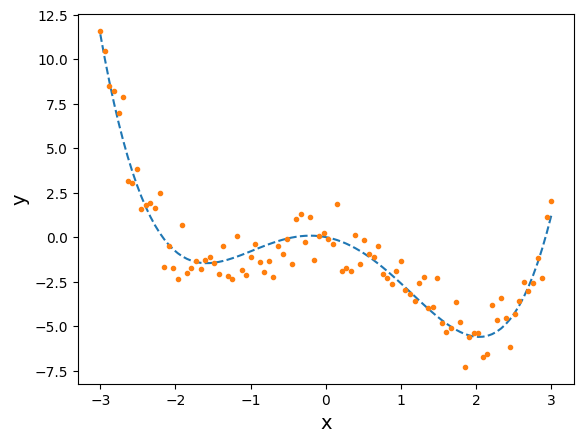

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1358)
x = np.linspace(-3,3, 100)
y_true = 0.3 * x**4 -0.1 * x**3 - 2* x**2 - 0.8*x
y = y_true + np.random.randn(len(x))
plt.plot(x,y_true, '--')
plt.plot(x,y, '.')
plt.xlabel('x', size=14)
plt.ylabel('y', size=14)

In [ ]:
from sklearn.metrics import mean_squared_error

np.random.seed(1358)
x = np.linspace(-3,3, 100)
y_true = 0.3 * x**4 -0.1 * x**3 - 2* x**2 - 0.8*x
y = y_true + np.random.randn(len(x))

result = {}

def mse_degree(degree):
    values = np.polyfit(x, y_true, degree)

    y_pred = np.polyval(values, x)

    return mean_squared_error(y, y_pred)

print(f'For degree 1: {mse_degree(1)}')
print(f'For degree 2: {mse_degree(2)}')
print(f'For degree 3: {mse_degree(3)}')
print(f'For degree 4: {mse_degree(4)}')
print(f'For degree 5: {mse_degree(5)}')

For degree 1: 6.151666926627784
For degree 2: 4.908098240734392
For degree 3: 4.574271982470261
For degree 4: 0.9721756268425612
For degree 5: 0.9721756268425586


#### Taks 3: Compute the derivatives of the following functions using sympy.

In [ ]:
x, y = symbols('x y')

# Definition of the expression
ex1 = x**2 + 2 * x + 1
solutions = diff(ex1, x)

solutions

2*x + 2

In [ ]:
ex2 = (3*x - 5)**3
solu = diff(ex2, x)
f = expand(solu)
f

81*x**2 - 270*x + 225

In [ ]:
from sympy import symbols, sqrt

ex3 = (sqrt(x) - 1)**2 - (x**2 + 1)**4
solu = diff(ex3, x)
f = expand(solu)
f

-8*x**7 - 24*x**5 - 24*x**3 - 8*x + 1 - 1/sqrt(x)

In [ ]:
from sympy import symbols, cot, acos, ln, exp, atan

ex4 = 7 * cot(x) -8 * acos(x)
solu = diff(ex4, x)
solu

-7*cot(x)**2 - 7 + 8/sqrt(1 - x**2)

In [ ]:
ex5 = x - ln(x) + 7
solu = diff(ex5, x)
solu

1 - 1/x

In [ ]:
ex6 = -10 * exp(x) + 5**x - 5*x + x/5
solu = diff(ex6, x)
solu
ex6

5**x - 24*x/5 - 10*exp(x)

In [ ]:
ex7 = 2*sin(x) / (sin(x)-cos(x))
solu = diff(ex7, x)
solu

2*(-sin(x) - cos(x))*sin(x)/(sin(x) - cos(x))**2 + 2*cos(x)/(sin(x) - cos(x))

In [ ]:
ex8 = x**2 * ln(x) / (1-atan(x))
solu = diff(ex8, x)
solu

x**2*log(x)/((1 - atan(x))**2*(x**2 + 1)) + 2*x*log(x)/(1 - atan(x)) + x/(1 - atan(x))

### Assignment for "Multivariable Calculus"

This task is associated with the "Insufficient" criterion in ILO 7.0. You need to complete the assignments 1-4 at the end of [this page](https://adsai.buas.nl/Study%20Content/Advanced%20Python/27.MultivariableCalculus.html)

Provide a link to a PDF file, for assignments 1-3 in the following cell. 

[A link to a PDF file for assignments 1-3](https://github.com/BredaUniversityADSAI/2023-24b-fai1-adsai-EmilFox231007/blob/8887e9a932796261c1d4fbdaf5e516042e9975ad/Data%20Lab%20Preparation/MulCalAss_231007.pdf)

Put your code  for assignment 4 in the following cell. (It was optional)

In [ ]:
# Put your code for assignment 4 here.

### Assignments for "Optimization Algorithms"

This task is associated with the "Sufficient" criterion in ILO 7.0. 

Complete the assignments at the end of [this page](https://adsai.buas.nl/Study%20Content/Advanced%20Python/29.OptimizationAlgorithms.html). Then put your code in the following cell.

### OptAlg_231007

#### Template for Assignment 1 

This is a template for **Assignment 1** of **Optimization and Linear Regression using Gradient Descent** (Monday of Week 8). 

Fill in the **None** part in this template. Feel free to add more cells to this notebook to perform all the tasks that you are asked to do.

The goal is to find the minimum of the following function:

$$f(x) =  0.3x^4 - 0.1x^3 - 2x^2 - 0.8x$$

using the Gradient Descent algorithm.

In [ ]:
# Put your code here (1 line of code)
# Import matplotlib.pyplot
import matplotlib.pyplot as plt

### Initilization

Consider an initial value for $𝑥$. You can initiate the Gradient Descent algorithm from any arbitrary starting point.

In [ ]:
# Put your code here (1 line of code)
# Consider an initial value for x
x = 5 # random value

###  Define function
Define the following function

$$f(x) =  0.3x^4 - 0.1x^3 - 2x^2 - 0.8x$$

You are tasked with finding the minimum for this function.

In [ ]:
def my_fun(x):
    # x (a scalar value): input value to your function
    
    # Output
    # y (scalar value): output of the function
    
    # Put your code here (1 line of code)
    y = 0.3*x**4 - 0.1*x**3 - 2*x**2 - 0.8*x
    
    return y

**Test your my_fun**:

To ensure that you have implemented *my_fun(.)* correctly, run the following cell and compare the output with the expected value.

In [ ]:
my_fun(-2)

-0.8000000000000003

The expected output is: -0.800

### Compute the gradient of the function

To implement the Gradient Descent algorithm, you need to compute the derivative of the related function. 

Now, compute the derivative of the mathematical function

$$ f(x) = 0.3x^4 -0.1x^3 -2x^2 -0.8x$$

and implement the following function for computing the derivative of this function:

In [ ]:
def grad_fun(x):
    # x (a scalar value): input to the derivative function
    # y (output of the derivative function)
    
    # Put your code here (1 line of code)
    y = 1.2*x**3 - 0.3*x**2 - 4*x - 0.8 #the derivative of the function
    
    return y

**Test grad_fun**:

Now, to ensure that you have computed and implemented the derivative function correctly, run the following cell and compare the result with the provided expected value.

In [ ]:
grad_fun(0.5)

-2.725

The expected output is: -2.725

### Implement Gradient Descent Update Rule

In this section, you need to implement the gradient descent update rule as follows:

$$x_{n+1} = x_n - \gamma \nabla f(x_n)$$

To execute this step, utilize the **grad_fun** that you have already implemented.

In [ ]:
def grad_descent_step(x, alf):
    # x (a scalar value): the current value of x
    # alf (a scalar value): learning rate
    # x_new: the new value for x
    
    # Put your code here (1 line of code)
    x_new = x - alf * grad_fun(x)
    
    return x_new

**Test grad_descent_step function**:

Now, test your implemented Gradient Descent update rule by running the following cell and comparing the result with the expected value.

In [ ]:
grad_descent_step(2.5, 0.1)

1.8925

The expected ouptput is: 1.8925

### Implement Gradient Descent Algorithm

Now, you can implement the Gradient Descent algorithm using the previously developed functions, enabling you to complete the assignment by finding the optimal value of x and minimizing the function.

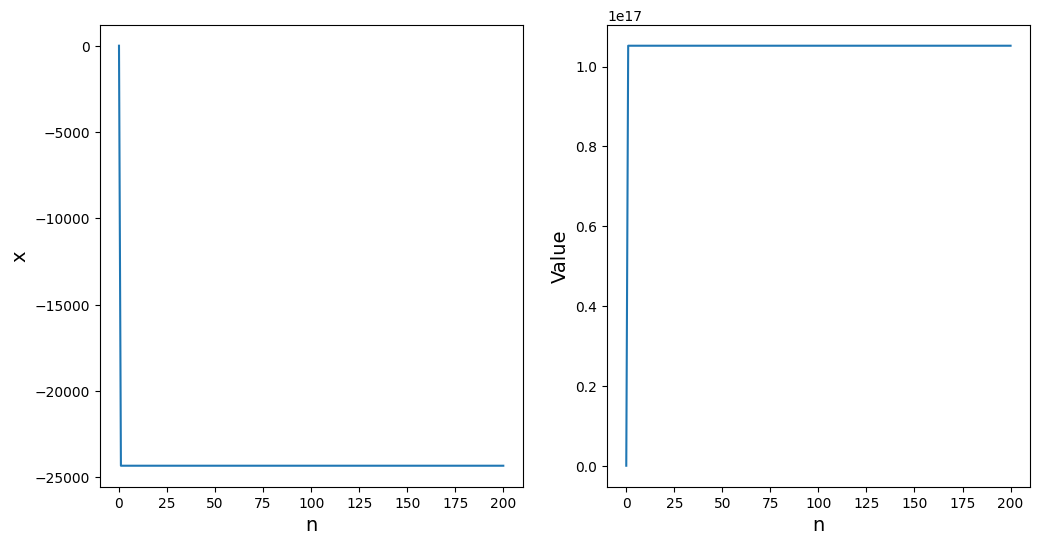

In [ ]:
# Put your code here (1 line of code)
# Choose an initial value for x
x_init = 3.0

# Put your code here (1 line of code)
# Choose the learning rate
gam = 0.001

# Put your code here (1 line of code)
# Choose the number of iterations
#N = None
N = 200

# Save the values for x and function value
X = [x_init]

# Save the function value at x_init
FUN_VAL = [my_fun(x_init)]

for n in range(N):
    
    # Put your code here (1 line of code)
    # call the grad_descent_step
    x_new = x - N * grad_fun(x)
    
    # Put your code here (2 lines of code)
    # save the obtained value x_new in the list X (use append method)
    # save the function value at point x_new (use append method)
    X.append(x_new)
    FUN_VAL.append(my_fun(x_new))

# Plot the results
fig, ax = plt.subplots(1,2, figsize=(12,6))
ax[0].plot(range(N+1), X)
ax[0].set_xlabel('n', size=14)
ax[0].set_ylabel('x', size=14)

ax[1].plot(range(N+1), FUN_VAL)
ax[1].set_xlabel('n', size=14)
ax[1].set_ylabel('Value', size=14)

plt.show()

**The optimal value for x**:

In [ ]:
# Put your code here (1 line of code)
# Define the optimal value for x
x_opt = 3.0

print("The optimal value of x is:", x_opt)

The optimal value of x is: 3.0


**The minimum value of the function**:

In [ ]:
# Put your code here (1 line of code)
# Define the minimum value of the function at optimal point x_opt
min_val = 0

print("The minimum value of f is:", min_val)

The minimum value of f is: 0


## Check the Result

Eventually, to ensure that you have implemented the Gradient Descent algorithm correctly, you can obtain the minimum value of the function using Python's capabilities.

You can check the Gradient Descent algorithm output by comparing the results obtained by the 'fmin' function from SciPy as follows:

In [ ]:
from scipy.optimize import fmin

minimum = fmin(my_fun, 3)

Optimization terminated successfully.
         Current function value: -5.608514
         Iterations: 16
         Function evaluations: 32


In [ ]:
print("The optimal value for x is:", minimum[0])

The optimal value for x is: 2.0421386718749974


## Implement Gradient Descent Algorithm for House Price Prediction

This is a template for Assignment 2 of **Optimization and Linear Regression using Gradient Descent** (Monday of Week 8).

Fill in the **None** part in this template. Feel free to add more cells to this notebook to perform all the tasks that you are asked to do.

The goal in this assignment is to build a linear regression model to predict the house price based on its size.

In [ ]:
# Put your code here (3 lines of code)
# Import numpy, pandas, and matplotlib.pyplot 
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [ ]:
# Put your code here (1 line of code)
# Load the dataset
data = pd.read_csv('C:\\Users\\emilp\\Downloads\\house-prices.csv')

In [ ]:
# Put your code here (1 line of code)
# Take a look at the data, use head method for data
data

,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
0,1,114300,1790,2,2,2,No,East
1,2,114200,2030,4,2,3,No,East
2,3,114800,1740,3,2,1,No,East
3,4,94700,1980,3,2,3,No,East
4,5,119800,2130,3,3,3,No,East
...,...,...,...,...,...,...,...,...
123,124,119700,1900,3,3,3,Yes,East
124,125,147900,2160,4,3,3,Yes,East
125,126,113500,2070,2,2,2,No,North
126,127,149900,2020,3,3,1,No,West


In [ ]:
# Select the size and price values from the dataset and assign them to 
# variables X and Y
X_dat = data['SqFt'].to_numpy()
Y_dat = data['Price'].to_numpy()

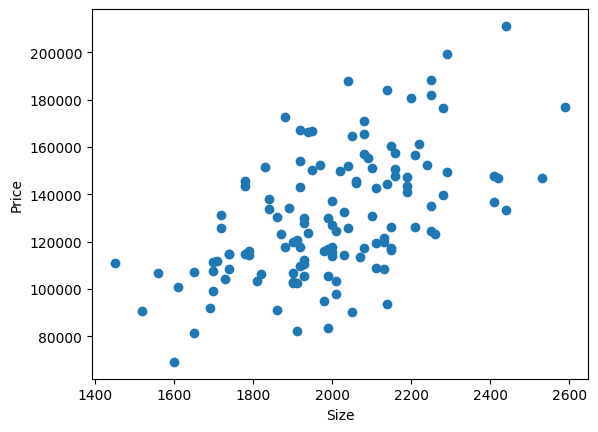

In [ ]:
# Put your code here (1 line of code)
# Plot a scatter plot for X_dat and Y_dat
# Take alook at our data
plt.scatter(X_dat, Y_dat, label='remarks of highsest points')

plt.xlabel('Size')
plt.ylabel('Price')
plt.show()

It is always good practice to normalize our data to increase the convergence rate of the Gradient Descent algorithm.

In [ ]:
# Normalize our data
X = (np.max(X_dat) - X_dat)/(np.max(X_dat) - np.min(X_dat)) 
Y = (np.max(Y_dat) - Y_dat)/(np.max(Y_dat) - np.min(Y_dat)) 

Now that our data is prepared, let's start creating the necessary functions to implement the Gradient Descent algorithm.

### Linear Regression Model

At first step, we need to define our linear regression model. The model is as follows:

$$y=wx+b$$

In [ ]:
# Define the linear regression model
def LR_model(x, w, b):
    # x: a scalar value, the size of the house
    # w: the weight of the model, a scalar value
    # b: the intercept of the model, a scalar value
    
    # Put your code here (1 line of code)
    # Define the linear regression model
    y = w * x + b
    
    return y

In [ ]:
# Implement the cost function (mean squared error function)
def cost(X, Y, w, b):
    # X: a vector contains the size of the houses
    # Y: a vector contains the price of the houses
    # w: weight of the linear regression model
    # b: intercept of the model
    
    # Number of the observations
    m = len(X)
    
    # Cost value
    
    # Put your code here (1 line of code)
    # Initilize the sum as zero 
    J = 0
    
    for i in range(m):
        x = X[i]
        y = Y[i]
        
        # Put your code here (1 line of code)
        # Use LR_model to compute the prediction of the price based on the size
        y_pred = w * x +b 
        
        # Put your code here (1 line of code)
        # Compute the cost function (mean squared error cost function)
        J = (y_pred - y)**2
    
    return J
    

To make sure that you have correctly implemented the cost function, run the following cell and compare the obtained result with the given value. 

In [ ]:
# Use your function to compute the cost for the following values
cost(X, Y, 2, 3)

8.92253490636514

The expected value is: 6.050766241298438

In [ ]:
def grad_descent_step(X, Y, w, b, alf):
    # X: a vector contains the size of the houses
    # Y: a vector contains the price of the houses
    # w: weight of the linear regression model
    # b: intercept of the model
    # alf: learning rate (a scalar value)
    
    # Number of the observations
    m = len(X)
    
    # Put your code here (2 lines of code)
    # Initilize both sum_w and sum_b as zero
    sum_w = 0
    sum_b = 0
    
    # A for loop to compute the sums appear in the update rule
    for i in range(m):
        x = X[i]
        y = Y[i]
        
        # Put your code here (1 line of code)
        # Use your LR_model to compute a prediction with x, w, b
        y_pred = LR_model(x,w,b) 
        
        # Put your code here (2 lines of code)
        # Compute the sums appear in the update rule
        sum_w = sum_w + (x * (y - y_pred)) / m
        sum_b = sum_b +(y - y_pred) / m 
    
    # Put your codes here (2 lines of code)
    # Implement the update rule for the gradien descent
    w_new = w - alf * sum_w
    b_new = b - alf * sum_b 
    
    return w_new, b_new

Now that you have implemented the Gradient Descent update rule, to ensure its correctness, run the following cell and compare your result with the provided one.

In [ ]:
grad_descent_step(X, Y, 2, -3, 0.01)

(1.9873921762558104, -3.02534978243793)

The expected values are as follows:
    
(2.0126078237441893, -2.97465021756207)

### Implement Gradient Descent Algorithm

Now, it is time to implement the Gradient Descent algorithm using your already developed functions.

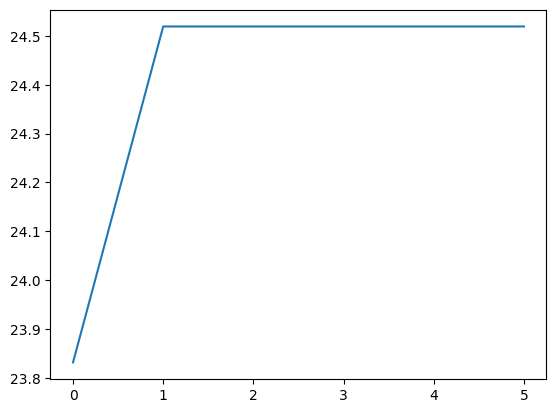

In [ ]:
# Put your code here (1 line of code)
# Choose an initial value for w
w_init = 5 

# Put your code here (1 line of code)
# Choose an initial value for b
b_init = 4

# Put your code here (1 line of code)
# Choose the learning rate
alf = 0.01

# Put your code here (1 line of code)
# Choose the number of iterations
N = 5

# Save the values for w, b
W = np.zeros(N + 1)
B = np.zeros(N + 1)
C = np.zeros(N + 1)

# Save initial values
W[0] = w_init
B[0] = b_init

# Put your code here (1 line of code)
# Save the cost for w_init and b_init using cost function
C[0] = cost(X, Y, w_init, b_init)

# A loop to iteratively apply the update rule 
for n in range(N):
    
    # Put your code here (1 line of code)
    # Use grad_descent_step function to find new values for w, b
    w_new, b_new = grad_descent_step(X, Y, w_init, b_init, alf)
    
    # Put your code here (2 lines of code)
    # Save the new values for w and b 
    W[n+1] = w_new
    B[n+1] = b_new
    
    # Put your code here (1 line of code)
    # Save the cost value for compute new values of w and b 
    # Use the cost function you have already implemented
    C[n+1] = cost(X, Y, w_new, b_new)

# Plot the results
plt.plot(range(N+1),C)
plt.show()

Now, plot the obtained results:

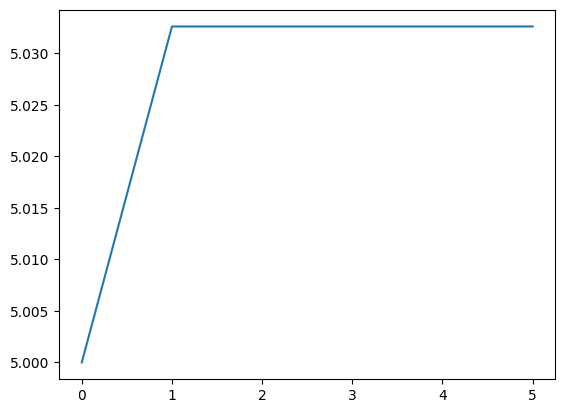

In [ ]:
# Put your code here (1 line of code)
# Plot the saved values of W against the iteration.
plt.plot(range(N + 1), W)

plt.show()

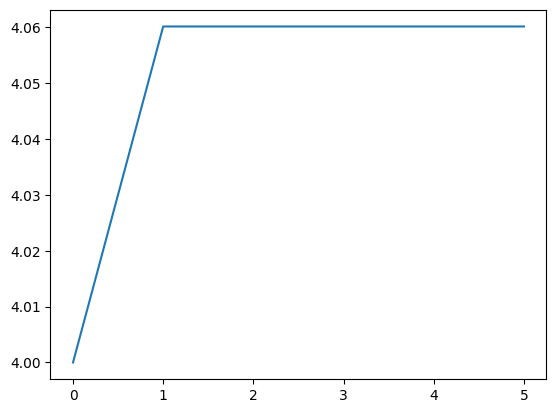

In [ ]:
# Put your code here (1 line of code)
# Plot the saved values of B against the iteration.
plt.plot(range(N + 1), B)

plt.show()

In [ ]:
# Put your code here (2 lines of code)
# Define the final values (optimal values) of w and b
w_opt = W[-1]
b_opt = B[-1]

print("The optimal value for w:", w_opt)
print("The optimal value for b:", b_opt)

The optimal value for w: 5.032597948705026
The optimal value for b: 4.060151862298913


Since we initially normalized the data, in this section, we inverse the normalization to represent the model using the initial values of the data.

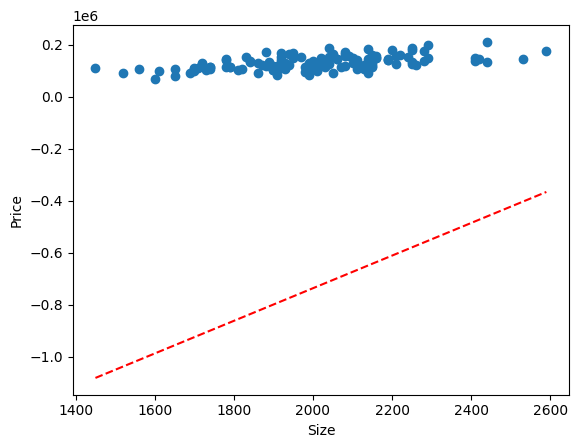

In [ ]:
X_max = np.max(X_dat)
X_min = np.min(X_dat)

Y_max = np.max(Y_dat)
Y_min = np.min(Y_dat)

X_line = np.linspace(X_min, X_max, 100)
Y_line_norm = w_opt * (X_max - X_line)/(X_max - X_min) + b_opt
Y_line = Y_max - Y_line_norm * (Y_max - Y_min) 
plt.plot(X_line,Y_line, 'r--')


plt.scatter(X_dat,Y_dat)

plt.xlabel('Size')
plt.ylabel('Price')
plt.show() 

### Compare with Scikit-learn

Congratulations! You have finished building a linear regression model from scratch. Perhaps you are curious to compare your model with the one obtained using the Scikit-learn package. In what follows, you will train the same model using Scikit-learn, and you can compare your model with that one.

In [ ]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression().fit(X.reshape(-1,1), Y)

In [ ]:
print("The optimal value for w:", reg.coef_)

The optimal value for w: [0.563392]


In [ ]:
print("The optimal value for b:", reg.intercept_)

The optimal value for b: 0.2773044733289968


If your model is significantly different from that of Scikit-learn, try to fine-tune the hyperparameters in your algorithm, such as the learning rate and the number of iterations. You should aim to achieve similar results.

Good Luck!

### Assignments for "DataLab: Linear Regression with Gradient Descent"

This task is associated with the "Good" and "Excellent" criteria in ILO 7.0. 

Complete the assignment at the end of [this page](https://adsai.buas.nl/Study%20Content/Advanced%20Python/30.LinearRegressionGradientDescentDataLab.html). Then put your code in the following cell.

In [ ]:
# Put your code here